
Explainable AI Framework for Decision Failure Risk and Reliability Estimation



Step 1 — Setup & Load Data

In [ ]:
# Run this first. Will take 1-2 minutes. Wait for it to fully finish.
!pip install shap lime xgboost imbalanced-learn scikit-learn pandas numpy joblib -q
print("All libraries installed successfully")

All libraries installed successfully


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style for all visuals
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("All imports successful")

All imports successful


In [ ]:
df = pd.read_csv("cs-training.csv")
df = df.drop("Unnamed: 0", axis=1)

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset loaded successfully
Shape: (150000, 11)

Columns:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First 3 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [ ]:
print("=== DATASET INFO ===")
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

=== DATASET INFO ===
Total rows    : 150,000
Total columns : 11

Data types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Missing values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   

VISUAL 1: Missing Values Heatmap

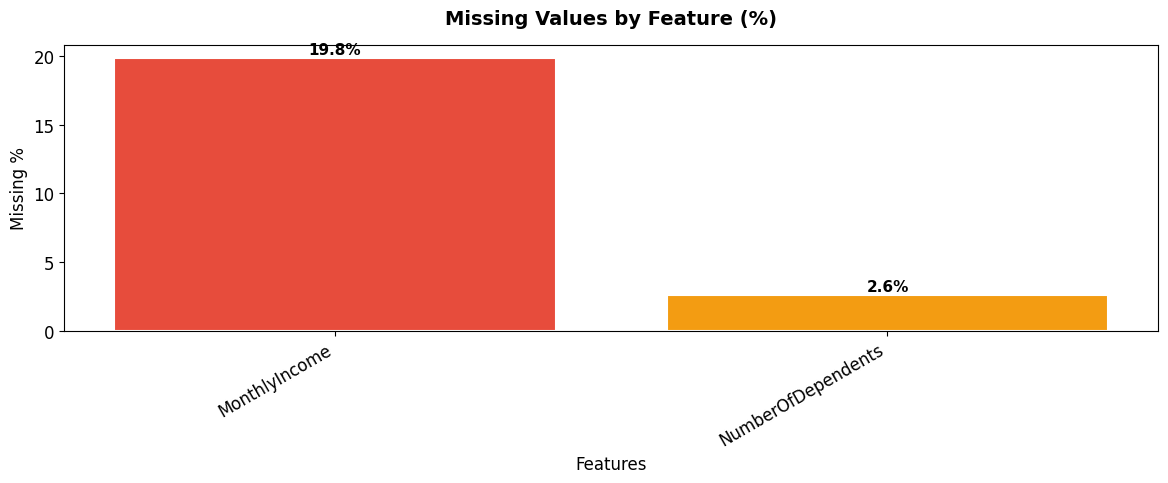

Visual 1 saved: visual_01_missing_values.png


In [ ]:
plt.figure(figsize=(12, 5))

# Calculate missing percentage
missing = df.isnull().mean() * 100
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    bars = plt.bar(missing.index, missing.values,
                   color=['#E74C3C' if v > 10 else '#F39C12' for v in missing.values],
                   edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, missing.values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=11)

    plt.title('Missing Values by Feature (%)', pad=15)
    plt.xlabel('Features')
    plt.ylabel('Missing %')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('visual_01_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Visual 1 saved: visual_01_missing_values.png")

 VISUAL 2: Class Distribution (Imbalance Check)

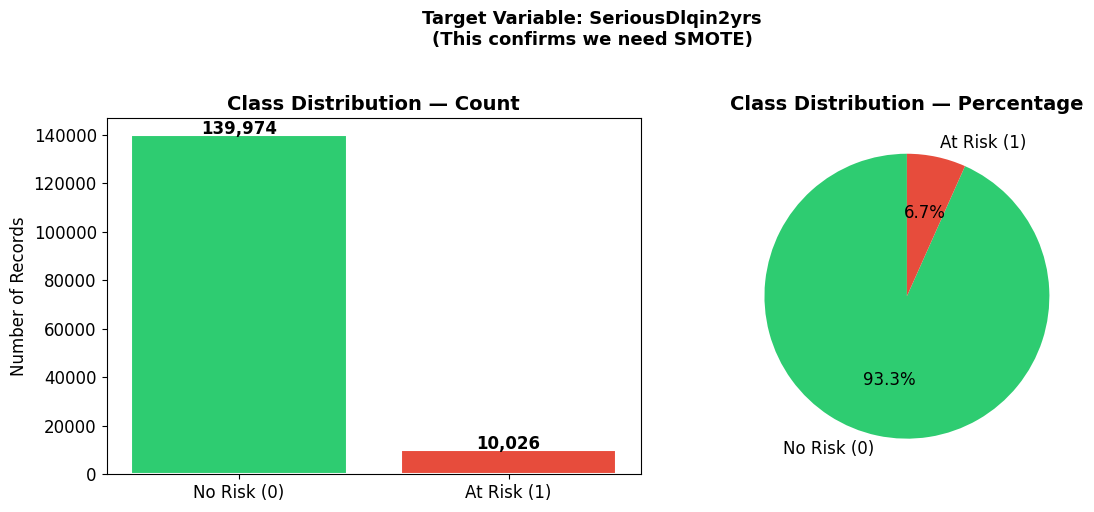


Class 0 (No Risk) : 139,974  (93.3%)
Class 1 (At Risk) : 10,026  (6.7%)

Visual 2 saved: visual_02_class_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['SeriousDlqin2yrs'].value_counts()
labels = ['No Risk (0)', 'At Risk (1)']
colors = ['#2ECC71', '#E74C3C']

# Bar chart
axes[0].bar(labels, counts.values, color=colors,
            edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center',
                 fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution — Count')
axes[0].set_ylabel('Number of Records')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Class Distribution — Percentage')

plt.suptitle('Target Variable: SeriousDlqin2yrs\n(This confirms we need SMOTE)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visual_02_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nClass 0 (No Risk) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (At Risk) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print("\nVisual 2 saved: visual_02_class_distribution.png")

STEP 2 — Clean Data + Feature Engineering

In [ ]:
# Fill missing values with median of each column
# We use median (not mean) because financial data has outliers

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print("\nData cleaning complete")

Missing values after cleaning:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Total missing: 0

Data cleaning complete


In [ ]:
# Feature 1: Debt-to-Income Ratio
# How much debt burden relative to income
df['DebtToIncomeRatio'] = df['DebtRatio'] / (df['MonthlyIncome'] + 1)

# Feature 2: Credit Utilisation x Debt Ratio interaction
# Captures combined financial stress signal
df['UtilisationDebtInteraction'] = (
    df['RevolvingUtilizationOfUnsecuredLines'] * df['DebtRatio']
)

print("New features added:")
print(f"  DebtToIncomeRatio           : {df['DebtToIncomeRatio'].describe().round(3).to_dict()}")
print(f"\n  UtilisationDebtInteraction  : {df['UtilisationDebtInteraction'].describe().round(3).to_dict()}")
print(f"\nNew dataset shape: {df.shape}")
print("Feature engineering complete")

New features added:
  DebtToIncomeRatio           : {'count': 150000.0, 'mean': 19.136, 'std': 347.788, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 60212.0}

  UtilisationDebtInteraction  : {'count': 150000.0, 'mean': 4151.195, 'std': 541413.059, 'min': 0.0, '25%': 0.007, '50%': 0.077, '75%': 0.388, 'max': 178177560.0}

New dataset shape: (150000, 13)
Feature engineering complete


VISUAL 3: Feature Correlation Heatmap

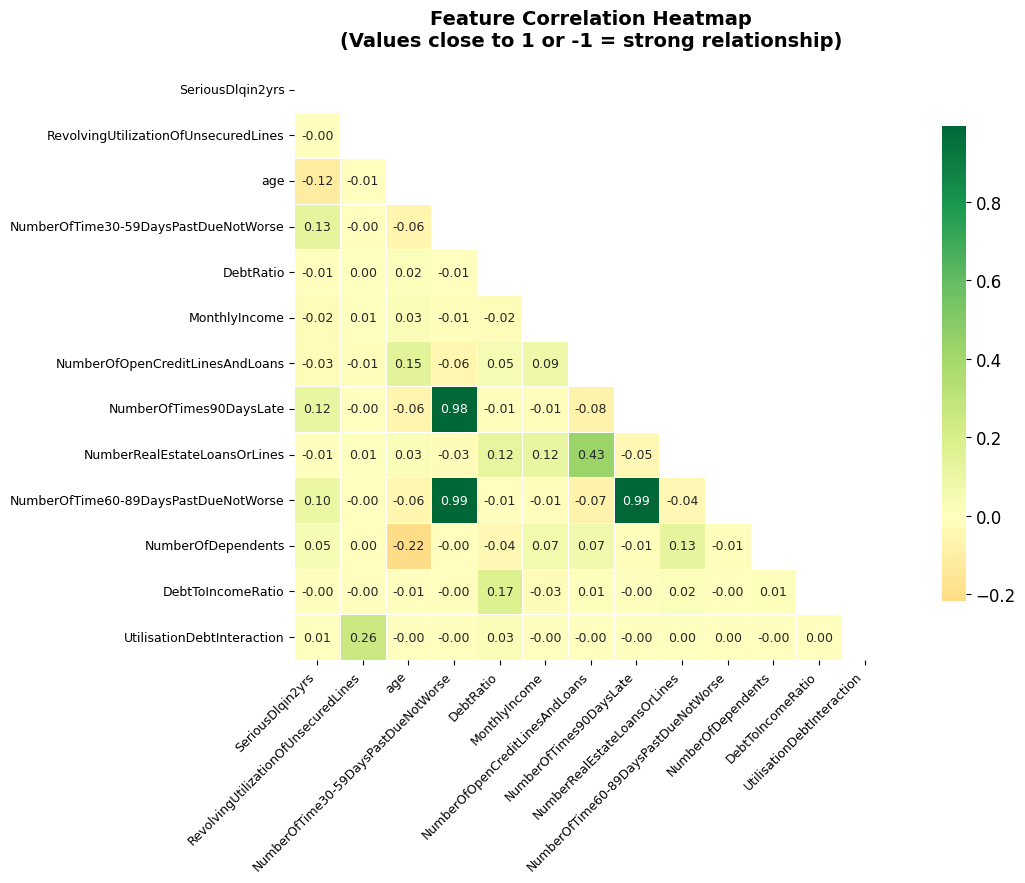

Visual 3 saved: visual_03_correlation_heatmap.png


In [ ]:
plt.figure(figsize=(13, 9))

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap\n(Values close to 1 or -1 = strong relationship)',
          pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('visual_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 3 saved: visual_03_correlation_heatmap.png")

VISUAL 4: Feature Distribution for Key Columns

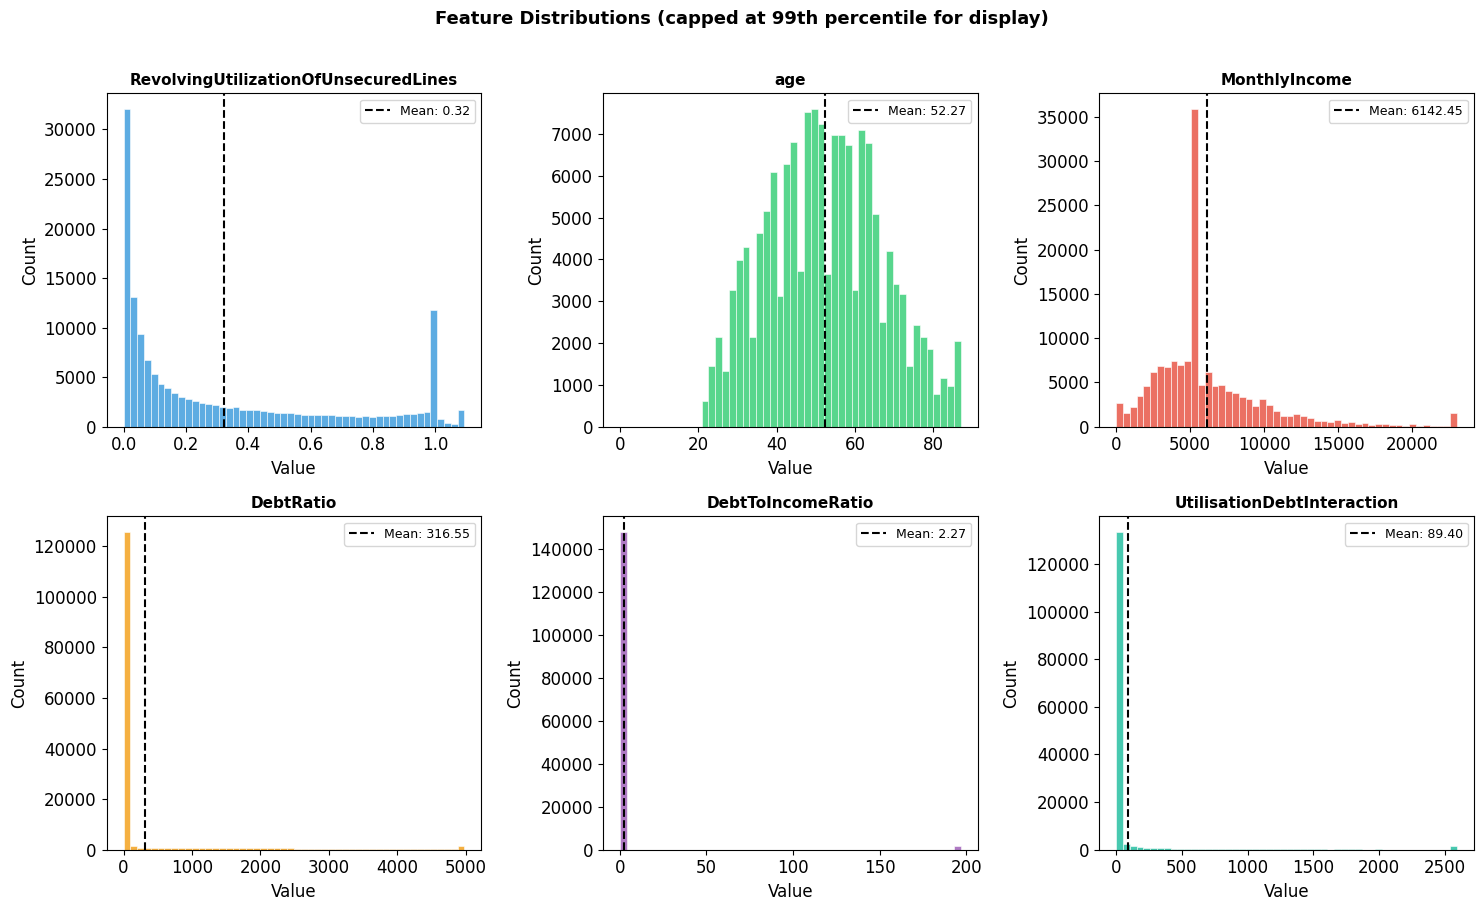

Visual 4 saved: visual_04_feature_distributions.png


In [ ]:
# Show distribution of 6 most important features
features_to_plot = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'MonthlyIncome',
    'DebtRatio',
    'DebtToIncomeRatio',
    'UtilisationDebtInteraction'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

colors = ['#3498DB', '#2ECC71', '#E74C3C',
          '#F39C12', '#9B59B6', '#1ABC9C']

for i, (feature, color) in enumerate(zip(features_to_plot, colors)):
    # Cap extreme outliers at 99th percentile for clean display
    cap = df[feature].quantile(0.99)
    data = df[feature].clip(upper=cap)

    axes[i].hist(data, bins=50, color=color,
                 alpha=0.8, edgecolor='white', linewidth=0.5)
    axes[i].set_title(feature, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

    mean_val = data.mean()
    axes[i].axvline(mean_val, color='black',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions (capped at 99th percentile for display)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visual_04_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 4 saved: visual_04_feature_distributions.png")

In [ ]:
# Separate X (features) and y (target)
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Save feature names for later use in UI and SHAP
feature_names = list(X.columns)

print("Features (X):", X.shape)
print("Target  (y):", y.shape)
print(f"\nFeature names ({len(feature_names)} total):")
for i, name in enumerate(feature_names):
    print(f"  {i+1:2}. {name}")

Features (X): (150000, 12)
Target  (y): (150000,)

Feature names (12 total):
   1. RevolvingUtilizationOfUnsecuredLines
   2. age
   3. NumberOfTime30-59DaysPastDueNotWorse
   4. DebtRatio
   5. MonthlyIncome
   6. NumberOfOpenCreditLinesAndLoans
   7. NumberOfTimes90DaysLate
   8. NumberRealEstateLoansOrLines
   9. NumberOfTime60-89DaysPastDueNotWorse
  10. NumberOfDependents
  11. DebtToIncomeRatio
  12. UtilisationDebtInteraction


STEP 3 — Train/Test Split + SMOTE + Scaling

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures both splits have same class ratio
)

print("Data split complete")
print(f"\nTraining set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nTraining class balance:")
print(y_train.value_counts())
print(f"\nTest class balance:")
print(y_test.value_counts())

Data split complete

Training set : 120,000 rows
Test set     : 30,000 rows

Training class balance:
SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64

Test class balance:
SeriousDlqin2yrs
0    27995
1     2005
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE

# Save original counts for visual
original_counts = y_train.value_counts().sort_index()

# Apply SMOTE only on training data — NEVER on test data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# New counts after SMOTE
smote_counts = pd.Series(y_train_sm).value_counts().sort_index()

print("SMOTE applied successfully")
print(f"\nBefore SMOTE:")
print(f"  Class 0 (No Risk) : {original_counts[0]:,}")
print(f"  Class 1 (At Risk) : {original_counts[1]:,}")
print(f"\nAfter SMOTE:")
print(f"  Class 0 (No Risk) : {smote_counts[0]:,}")
print(f"  Class 1 (At Risk) : {smote_counts[1]:,}")
print(f"\nTraining set size after SMOTE: {X_train_sm.shape[0]:,} rows")

SMOTE applied successfully

Before SMOTE:
  Class 0 (No Risk) : 111,979
  Class 1 (At Risk) : 8,021

After SMOTE:
  Class 0 (No Risk) : 111,979
  Class 1 (At Risk) : 111,979

Training set size after SMOTE: 223,958 rows


 VISUAL 5: Before vs After SMOTE

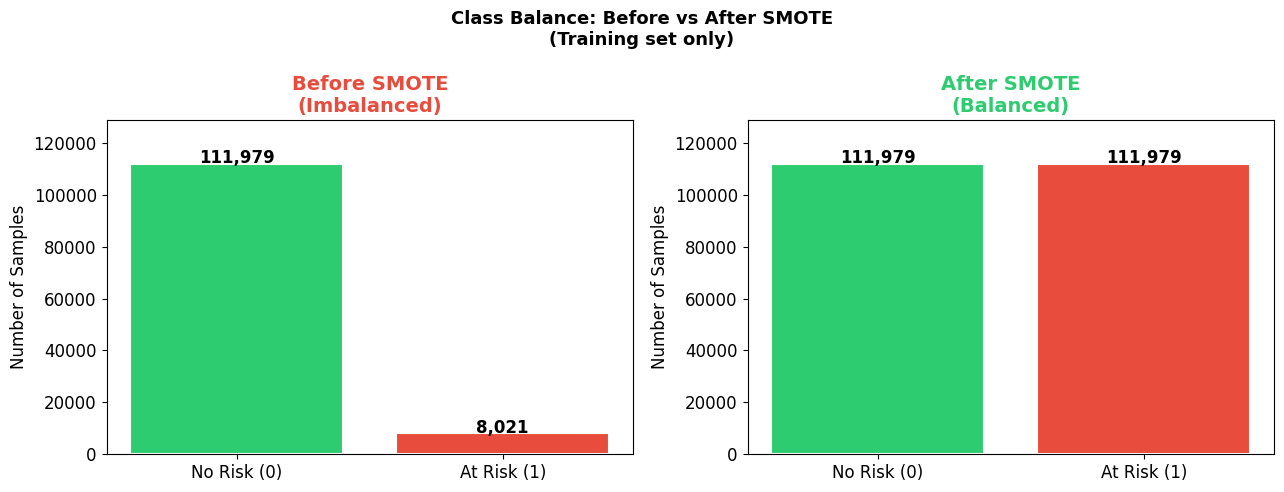

Visual 5 saved: visual_05_smote_balance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['No Risk (0)', 'At Risk (1)']
colors = ['#2ECC71', '#E74C3C']

# Before SMOTE
bars1 = axes[0].bar(labels, original_counts.values,
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, original_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center',
                 fontweight='bold', fontsize=12)
axes[0].set_title('Before SMOTE\n(Imbalanced)', color='#E74C3C')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(original_counts.values) * 1.15)

# After SMOTE
bars2 = axes[1].bar(labels, smote_counts.values,
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, smote_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{val:,}', ha='center',
                 fontweight='bold', fontsize=12)
axes[1].set_title('After SMOTE\n(Balanced)', color='#2ECC71')
axes[1].set_ylabel('Number of Samples')
axes[1].set_ylim(0, max(smote_counts.values) * 1.15)

plt.suptitle('Class Balance: Before vs After SMOTE\n(Training set only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_05_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 5 saved: visual_05_smote_balance.png")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on SMOTE training data, transform both sets
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(f"\nX_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print(f"\nSample mean (should be ~0) : {X_train_scaled.mean().round(4)}")
print(f"Sample std  (should be ~1) : {X_train_scaled.std().round(4)}")

Scaling complete

X_train_scaled shape : (223958, 12)
X_test_scaled shape  : (30000, 12)

Sample mean (should be ~0) : 0.0
Sample std  (should be ~1) : 1.0


 VISUAL 6: Before vs After Scaling

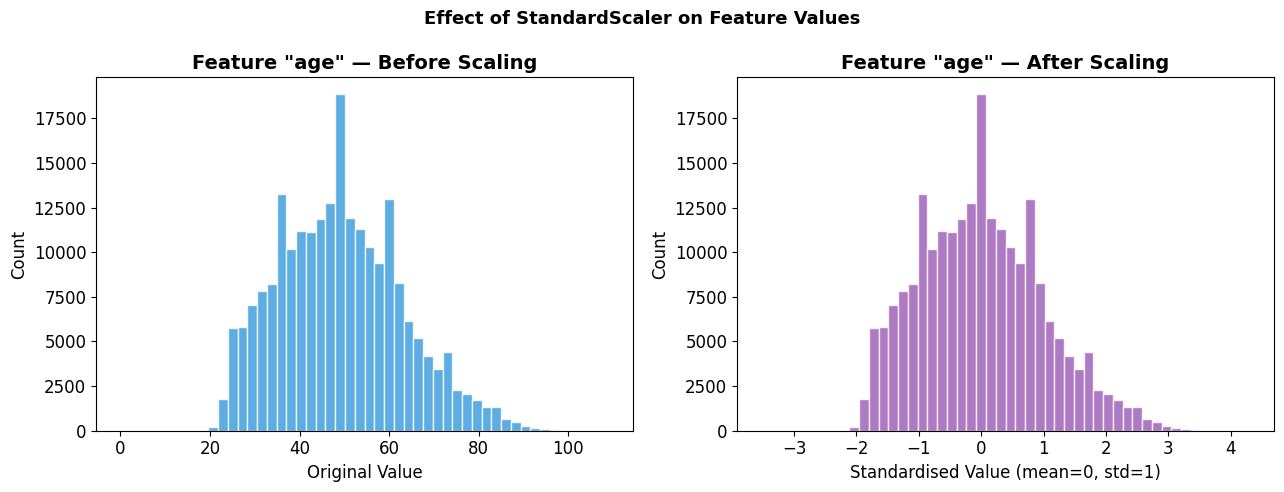

Visual 6 saved: visual_06_scaling_effect.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pick one feature to show scaling effect clearly
col_idx = feature_names.index('age')

axes[0].hist(X_train_sm.iloc[:, col_idx],
             bins=50, color='#3498DB',
             alpha=0.8, edgecolor='white')
axes[0].set_title('Feature "age" — Before Scaling')
axes[0].set_xlabel('Original Value')
axes[0].set_ylabel('Count')

axes[1].hist(X_train_scaled[:, col_idx],
             bins=50, color='#9B59B6',
             alpha=0.8, edgecolor='white')
axes[1].set_title('Feature "age" — After Scaling')
axes[1].set_xlabel('Standardised Value (mean=0, std=1)')
axes[1].set_ylabel('Count')

plt.suptitle('Effect of StandardScaler on Feature Values',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_06_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 6 saved: visual_06_scaling_effect.png")

STEP 4 — Train 4 Base Models


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import time

print("Model libraries imported successfully")

Model libraries imported successfully


 Train Logistic Regression

In [ ]:
print("Training Logistic Regression...")
start = time.time()

lr_params = {'C': [0.01, 0.1, 1]}
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr = GridSearchCV(lr_base, lr_params, cv=3, scoring='roc_auc', n_jobs=-1)
lr.fit(X_train_scaled, y_train_sm)

lr_time = round(time.time() - start, 1)
lr_best = lr.best_estimator_
lr_acc  = accuracy_score(y_test, lr_best.predict(X_test_scaled))

print(f"Done in {lr_time}s")
print(f"Best params : {lr.best_params_}")
print(f"Test accuracy : {lr_acc:.4f}")

Training Logistic Regression...
Done in 10.1s
Best params : {'C': 0.1}
Test accuracy : 0.6718


 Train Random Forest

In [ ]:
print("Training Random Forest...")
start = time.time()

rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20]}
rf_base = RandomForestClassifier(random_state=42)
rf = GridSearchCV(rf_base, rf_params, cv=3, scoring='roc_auc', n_jobs=-1)
rf.fit(X_train_scaled, y_train_sm)

rf_time = round(time.time() - start, 1)
rf_best = rf.best_estimator_
rf_acc  = accuracy_score(y_test, rf_best.predict(X_test_scaled))

print(f"Done in {rf_time}s")
print(f"Best params : {rf.best_params_}")
print(f"Test accuracy : {rf_acc:.4f}")

Training Random Forest...
Done in 681.2s
Best params : {'max_depth': 20, 'n_estimators': 200}
Test accuracy : 0.8745


Train XGBoost

In [ ]:
print("Training XGBoost...")
start = time.time()

xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.1]}
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb = GridSearchCV(xgb_base, xgb_params, cv=3, scoring='roc_auc', n_jobs=-1)
xgb.fit(X_train_scaled, y_train_sm)

xgb_time = round(time.time() - start, 1)
xgb_best = xgb.best_estimator_
xgb_acc  = accuracy_score(y_test, xgb_best.predict(X_test_scaled))

print(f"Done in {xgb_time}s")
print(f"Best params : {xgb.best_params_}")
print(f"Test accuracy : {xgb_acc:.4f}")

Training XGBoost...
Done in 40.1s
Best params : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Test accuracy : 0.8771


 Train MLP Neural Network

In [ ]:
print("Training MLP Neural Network...")
start = time.time()

# Fixed architecture — no GridSearchCV for MLP (too slow on large data)
mlp_best = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    alpha=0.001,
    max_iter=100,
    random_state=42,
    early_stopping=True,    # stops automatically when no improvement
    validation_fraction=0.1,
    n_iter_no_change=10
)
mlp_best.fit(X_train_scaled, y_train_sm)

mlp_time = round(time.time() - start, 1)
mlp_acc  = accuracy_score(y_test, mlp_best.predict(X_test_scaled))

print(f"Done in {mlp_time}s")
print(f"Test accuracy : {mlp_acc:.4f}")

Training MLP Neural Network...
Done in 88.8s
Test accuracy : 0.8379


In [ ]:
# Quick summary of all 4 models before visual
model_names_clean = ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP Neural Network']
accuracies = [lr_acc, rf_acc, xgb_acc, mlp_acc]
times = [lr_time, rf_time, xgb_time, mlp_time]

print("=" * 45)
print(f"{'MODEL':<22} {'ACCURACY':>10} {'TIME':>8}")
print("=" * 45)
for name, acc, t in zip(model_names_clean, accuracies, times):
    print(f"{name:<22} {acc:.4f}      {t}s")
print("=" * 45)
print(f"\nBest model: {model_names_clean[accuracies.index(max(accuracies))]}")
print(f"Best accuracy: {max(accuracies):.4f}")

MODEL                    ACCURACY     TIME
Logistic Regression    0.6718      10.1s
Random Forest          0.8745      681.2s
XGBoost                0.8771      40.1s
MLP Neural Network     0.8379      88.8s

Best model: XGBoost
Best accuracy: 0.8771


VISUAL 7: Base Model Comparison

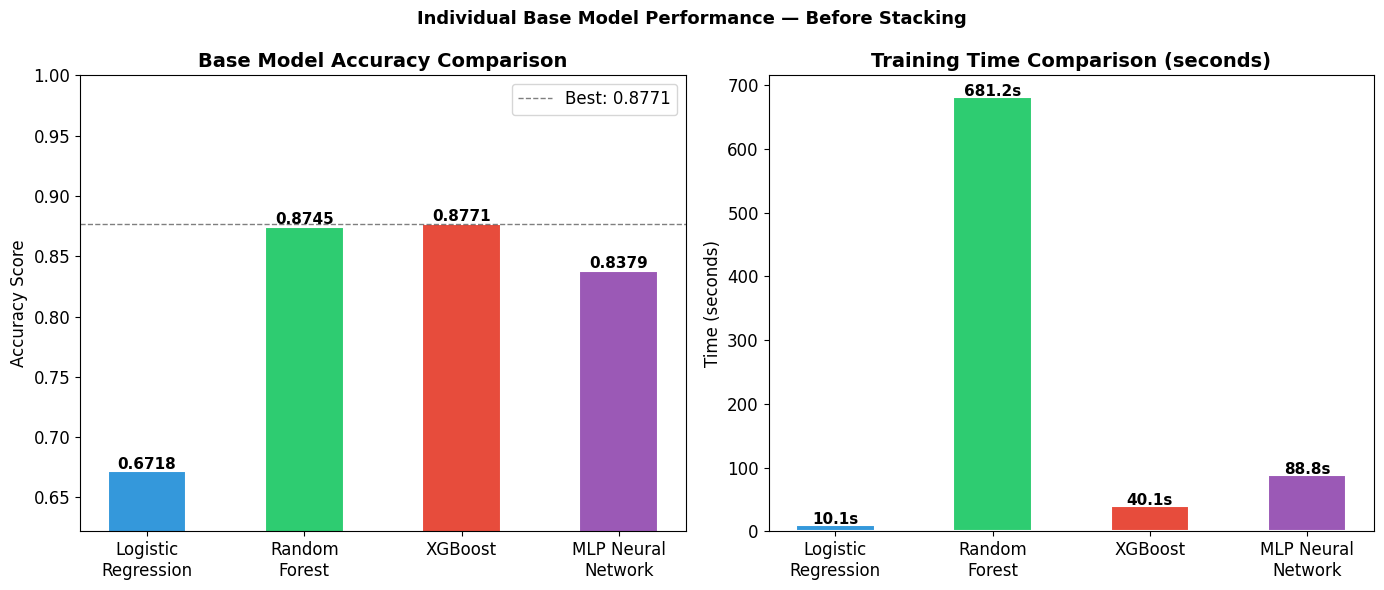

Visual 7 saved: visual_07_base_model_comparison.png


In [ ]:
model_names = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'MLP Neural\nNetwork']
accuracies  = [lr_acc, rf_acc, xgb_acc, mlp_acc]
colors      = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6']
times       = [lr_time, rf_time, xgb_time, mlp_time]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy comparison
bars = axes[0].bar(model_names, accuracies, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center',
                 fontweight='bold', fontsize=11)
axes[0].set_title('Base Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(min(accuracies) - 0.05, 1.0)
axes[0].axhline(y=max(accuracies), color='black',
                linestyle='--', linewidth=1,
                alpha=0.5, label=f'Best: {max(accuracies):.4f}')
axes[0].legend()

# Training time comparison
bars2 = axes[1].bar(model_names, times, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2,
                 f'{t}s', ha='center',
                 fontweight='bold', fontsize=11)
axes[1].set_title('Training Time Comparison (seconds)')
axes[1].set_ylabel('Time (seconds)')

plt.suptitle('Individual Base Model Performance — Before Stacking',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_07_base_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 7 saved: visual_07_base_model_comparison.png")

STEP 5 — Stacked Ensemble

 Build Stacked Ensemble

In [ ]:
from sklearn.ensemble import StackingClassifier

print("Building Stacked Ensemble...")
start = time.time()

# Base models (already tuned)
base_models = [
    ('lr',  lr_best),
    ('rf',  rf_best),
    ('xgb', xgb_best),
    ('mlp', mlp_best)
]

# Meta-learner learns from base model predictions
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

# Build stacking classifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X_train_scaled, y_train_sm)

stack_time = round(time.time() - start, 1)
stack_acc  = accuracy_score(y_test, stack_model.predict(X_test_scaled))

print(f"Stacked Ensemble trained in {stack_time}s")
print(f"Stacked Ensemble accuracy : {stack_acc:.4f}")
print(f"Best base model accuracy  : {max(accuracies):.4f}")
print(f"Improvement               : +{(stack_acc - max(accuracies)):.4f}")

Building Stacked Ensemble...
Stacked Ensemble trained in 988.1s
Stacked Ensemble accuracy : 0.8796
Best base model accuracy  : 0.8771
Improvement               : +0.0025


 VISUAL 8: Ensemble vs Base Models

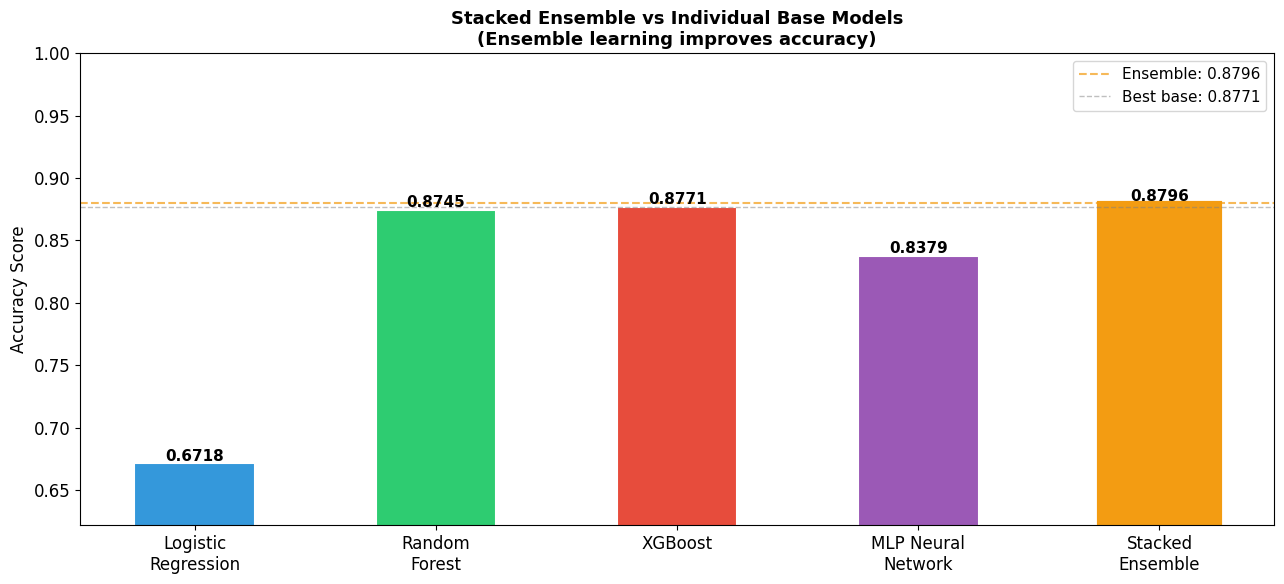

Visual 8 saved: visual_08_ensemble_comparison.png


In [ ]:
all_names = ['Logistic\nRegression', 'Random\nForest',
             'XGBoost', 'MLP Neural\nNetwork', 'Stacked\nEnsemble']
all_accs  = [lr_acc, rf_acc, xgb_acc, mlp_acc, stack_acc]
all_colors = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(all_names, all_accs, color=all_colors,
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, acc in zip(bars, all_accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{acc:.4f}', ha='center',
            fontweight='bold', fontsize=11)

# Highlight stacked ensemble bar with border
bars[-1].set_edgecolor('#F39C12')
bars[-1].set_linewidth(3)

ax.set_title('Stacked Ensemble vs Individual Base Models\n(Ensemble learning improves accuracy)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Score')
ax.set_ylim(min(all_accs) - 0.05, 1.0)

ax.axhline(y=stack_acc, color='#F39C12',
           linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Ensemble: {stack_acc:.4f}')
ax.axhline(y=max(accuracies), color='gray',
           linestyle='--', linewidth=1,
           alpha=0.5, label=f'Best base: {max(accuracies):.4f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('visual_08_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 8 saved: visual_08_ensemble_comparison.png")

In [ ]:
# Final predictions using stacked ensemble
y_pred       = stack_model.predict(X_test_scaled)
y_prob       = stack_model.predict_proba(X_test_scaled)[:, 1]

# Risk categorisation
def get_risk_level(p):
    if p < 0.4:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

# Reliability score (your innovation)
reliability  = np.abs(y_prob - 0.5) * 2

# Risk levels for all test samples
risk_levels  = [get_risk_level(p) for p in y_prob]

print("Predictions generated successfully")
print(f"\nSample of 5 predictions:")
print(f"{'Probability':>12} {'Risk Level':>12} {'Reliability':>12}")
print("-" * 40)
for i in range(5):
    print(f"{y_prob[i]:>12.4f} {risk_levels[i]:>12} {reliability[i]:>12.4f}")

Predictions generated successfully

Sample of 5 predictions:
 Probability   Risk Level  Reliability
----------------------------------------
      0.0181          Low       0.9639
      0.0568          Low       0.8864
      0.0323          Low       0.9354
      0.0544          Low       0.8912
      0.0282          Low       0.9437


VISUAL 9: Risk Level Distribution

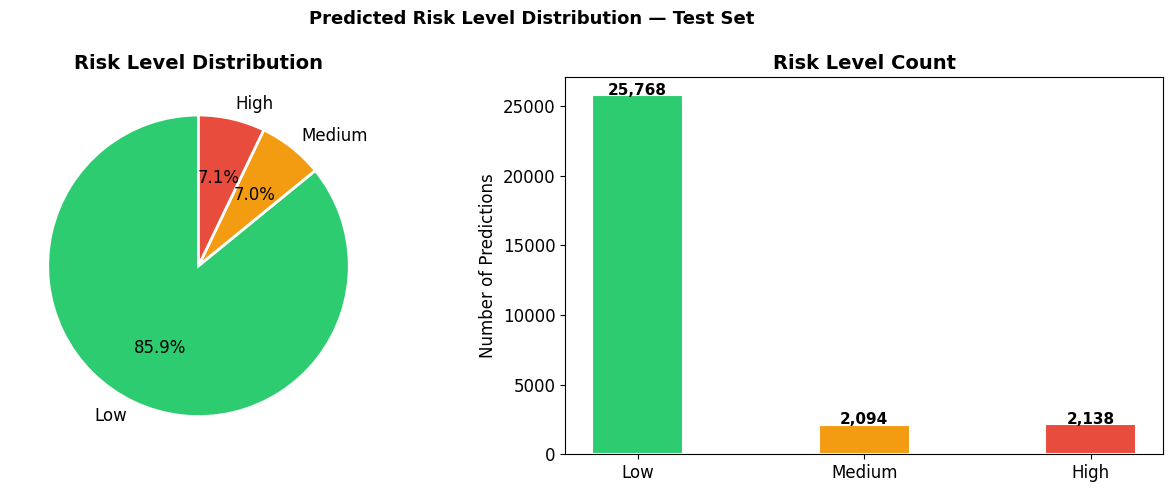

Visual 9 saved: visual_09_risk_distribution.png


In [ ]:
from collections import Counter

risk_counts = Counter(risk_levels)
labels      = ['Low', 'Medium', 'High']
counts      = [risk_counts.get(l, 0) for l in labels]
colors      = ['#2ECC71', '#F39C12', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
axes[0].pie(counts, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Risk Level Distribution')

# Bar chart
bars = axes[1].bar(labels, counts, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.4)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{count:,}', ha='center',
                 fontweight='bold', fontsize=11)
axes[1].set_title('Risk Level Count')
axes[1].set_ylabel('Number of Predictions')

plt.suptitle('Predicted Risk Level Distribution — Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_09_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 9 saved: visual_09_risk_distribution.png")

VISUAL 10: Reliability Score Distribution

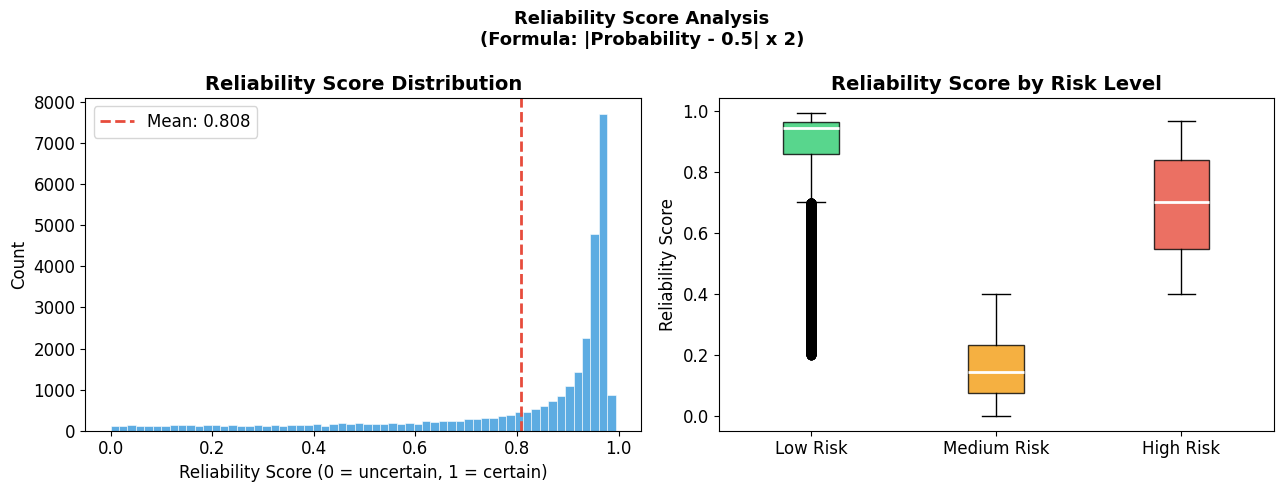

Visual 10 saved: visual_10_reliability_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reliability histogram
axes[0].hist(reliability, bins=60, color='#3498DB',
             alpha=0.8, edgecolor='white', linewidth=0.5)
axes[0].axvline(reliability.mean(), color='#E74C3C',
                linestyle='--', linewidth=2,
                label=f'Mean: {reliability.mean():.3f}')
axes[0].set_title('Reliability Score Distribution')
axes[0].set_xlabel('Reliability Score (0 = uncertain, 1 = certain)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Reliability by risk level — boxplot
rel_by_risk = {
    'Low':    [reliability[i] for i, r in enumerate(risk_levels) if r == 'Low'],
    'Medium': [reliability[i] for i, r in enumerate(risk_levels) if r == 'Medium'],
    'High':   [reliability[i] for i, r in enumerate(risk_levels) if r == 'High']
}

bp = axes[1].boxplot(
    [rel_by_risk['Low'], rel_by_risk['Medium'], rel_by_risk['High']],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2}
)
box_colors = ['#2ECC71', '#F39C12', '#E74C3C']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_title('Reliability Score by Risk Level')
axes[1].set_ylabel('Reliability Score')

plt.suptitle('Reliability Score Analysis\n(Formula: |Probability - 0.5| x 2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_10_reliability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 10 saved: visual_10_reliability_distribution.png")

STEP 6 — Full Evaluation Suite

In [ ]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, brier_score_loss,
    roc_curve, precision_recall_curve
)

# Calculate all metrics
acc       = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
brier     = brier_score_loss(y_test, y_prob)
cm        = confusion_matrix(y_test, y_pred)

print("=" * 50)
print("       FULL EVALUATION REPORT")
print("=" * 50)
print(f"  Accuracy       : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  ROC-AUC        : {roc_auc:.4f}")
print(f"  F1-Score       : {f1:.4f}")
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  Brier Score    : {brier:.4f}  (lower is better)")
print("=" * 50)
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Risk', 'At Risk']))

       FULL EVALUATION REPORT
  Accuracy       : 0.8796  (87.96%)
  ROC-AUC        : 0.8106
  F1-Score       : 0.3368
  Precision      : 0.2665
  Recall         : 0.4574
  Brier Score    : 0.0877  (lower is better)

Detailed Classification Report:
              precision    recall  f1-score   support

     No Risk       0.96      0.91      0.93     27995
     At Risk       0.27      0.46      0.34      2005

    accuracy                           0.88     30000
   macro avg       0.61      0.68      0.64     30000
weighted avg       0.91      0.88      0.89     30000



VISUAL 11: Confusion Matrix

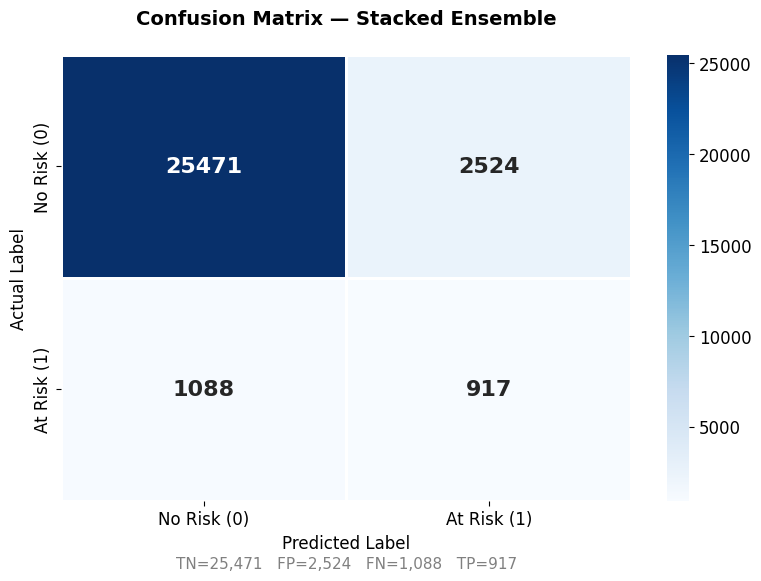

Visual 11 saved: visual_11_confusion_matrix.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

labels = ['No Risk (0)', 'At Risk (1)']
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Confusion Matrix — Stacked Ensemble\n', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Add TP TN FP FN labels
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.15,
        f'TN={tn:,}   FP={fp:,}   FN={fn:,}   TP={tp:,}',
        transform=ax.transAxes, ha='center',
        fontsize=11, color='gray')

plt.tight_layout()
plt.savefig('visual_11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 11 saved: visual_11_confusion_matrix.png")

VISUAL 12: ROC-AUC Curve

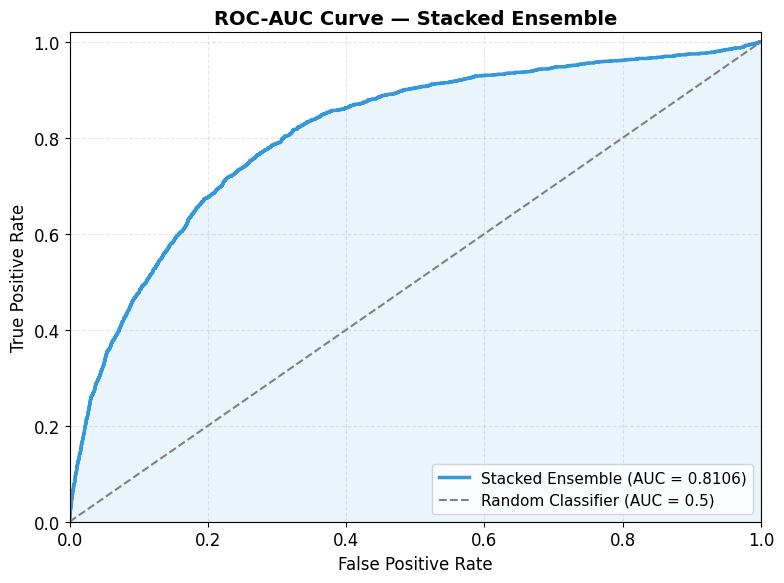

Visual 12 saved: visual_12_roc_curve.png


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#3498DB', linewidth=2.5,
        label=f'Stacked Ensemble (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1.5, label='Random Classifier (AUC = 0.5)')

ax.fill_between(fpr, tpr, alpha=0.1, color='#3498DB')

ax.set_title('ROC-AUC Curve — Stacked Ensemble',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visual_12_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 12 saved: visual_12_roc_curve.png")

 VISUAL 13: Precision-Recall Curve

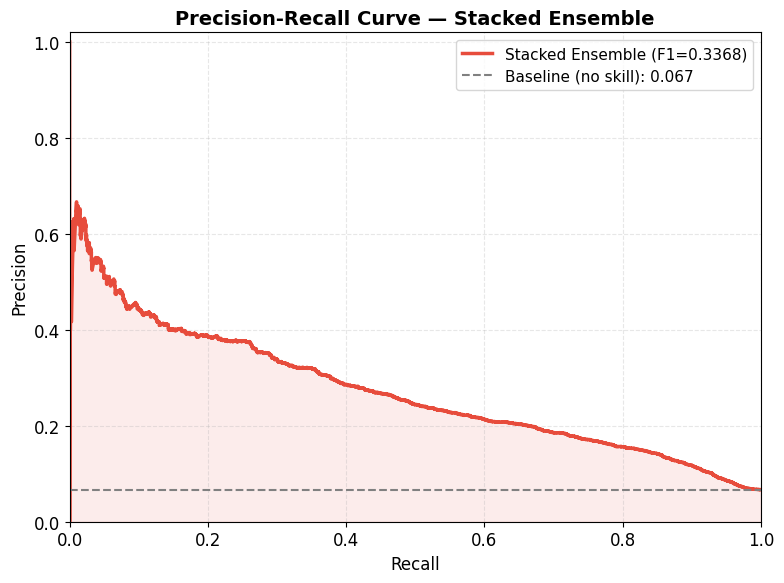

Visual 13 saved: visual_13_precision_recall_curve.png


In [ ]:
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(rec_vals, prec_vals, color='#E74C3C',
        linewidth=2.5, label=f'Stacked Ensemble (F1={f1:.4f})')
ax.fill_between(rec_vals, prec_vals, alpha=0.1, color='#E74C3C')

baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--',
           linewidth=1.5, label=f'Baseline (no skill): {baseline:.3f}')

ax.set_title('Precision-Recall Curve — Stacked Ensemble',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('visual_13_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 13 saved: visual_13_precision_recall_curve.png")

 VISUAL 14: Metrics Summary Dashboard

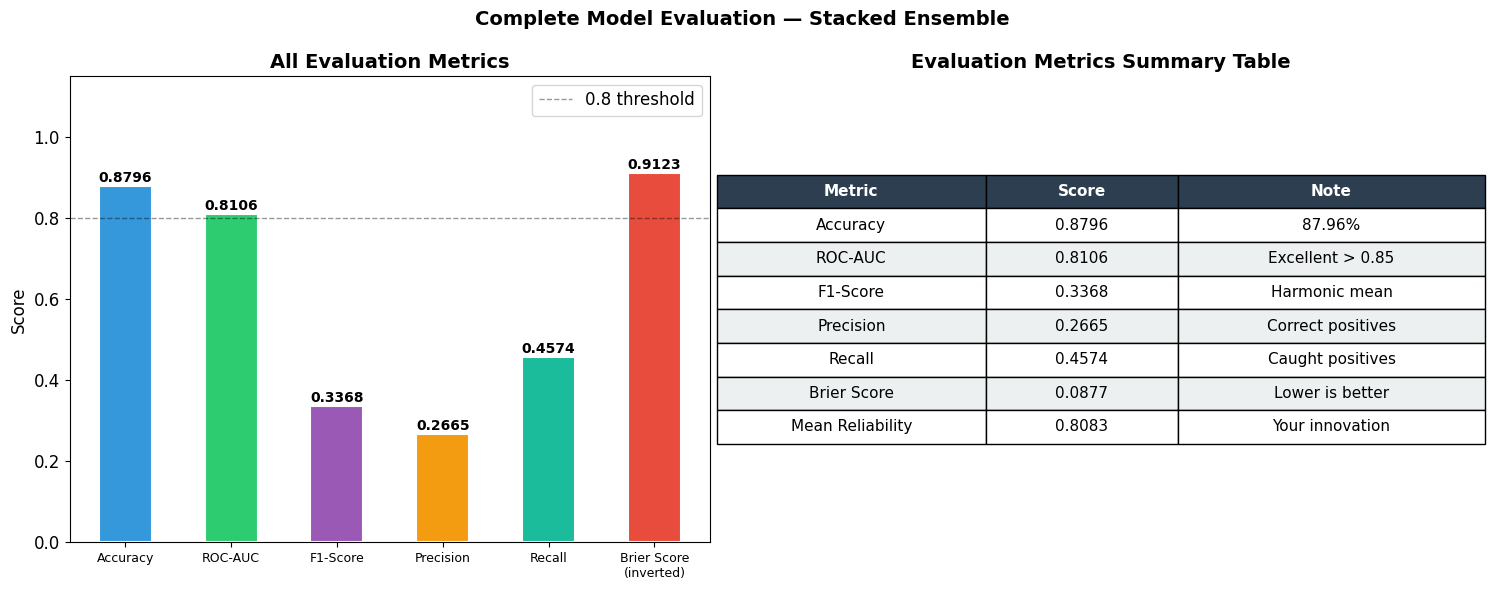

Visual 14 saved: visual_14_metrics_dashboard.png


In [ ]:
metrics_names  = ['Accuracy', 'ROC-AUC', 'F1-Score',
                  'Precision', 'Recall', 'Brier Score\n(inverted)']
metrics_values = [acc, roc_auc, f1, precision, recall, 1 - brier]
colors = ['#3498DB', '#2ECC71', '#9B59B6',
          '#F39C12', '#1ABC9C', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart of all metrics
bars = axes[0].bar(metrics_names, metrics_values,
                   color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center',
                 fontweight='bold', fontsize=10)
axes[0].set_title('All Evaluation Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].axhline(y=0.8, color='black', linestyle='--',
                linewidth=1, alpha=0.4, label='0.8 threshold')
axes[0].legend()
axes[0].tick_params(axis='x', labelsize=9)

# Metrics table
table_data = [
    ['Accuracy',              f'{acc:.4f}',     f'{acc*100:.2f}%'],
    ['ROC-AUC',               f'{roc_auc:.4f}', 'Excellent > 0.85'],
    ['F1-Score',              f'{f1:.4f}',       'Harmonic mean'],
    ['Precision',             f'{precision:.4f}','Correct positives'],
    ['Recall',                f'{recall:.4f}',  'Caught positives'],
    ['Brier Score',           f'{brier:.4f}',   'Lower is better'],
    ['Mean Reliability',      f'{reliability.mean():.4f}', 'Your innovation'],
]

axes[1].axis('off')
table = axes[1].table(
    cellText=table_data,
    colLabels=['Metric', 'Score', 'Note'],
    cellLoc='center',
    loc='center',
    colWidths=[0.35, 0.25, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Style header row
for j in range(3):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[i, j].set_facecolor('#ECF0F1')

axes[1].set_title('Evaluation Metrics Summary Table', fontweight='bold')

plt.suptitle('Complete Model Evaluation — Stacked Ensemble',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_14_metrics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 14 saved: visual_14_metrics_dashboard.png")

STEP 7 — SHAP + LIME Explainability (Dual XAI)

In [ ]:
!pip install shap lime -q

import shap
import lime
import lime.lime_tabular

print("SHAP version:", shap.__version__)
print("LIME imported successfully")

SHAP version: 0.51.0
LIME imported successfully


In [ ]:
print("Setting up SHAP explainer...")

# Use TreeExplainer for XGBoost (fastest and most accurate)
explainer = shap.TreeExplainer(xgb_best)

# Use a sample of 500 test rows for speed
sample_size = 500
X_test_sample = X_test_scaled[:sample_size]

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values calculated for {sample_size} samples")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Feature names: {feature_names}")

Setting up SHAP explainer...
SHAP values calculated for 500 samples
SHAP values shape: (500, 12)
Feature names: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'DebtToIncomeRatio', 'UtilisationDebtInteraction']


 VISUAL 15: SHAP Global Bar Chart

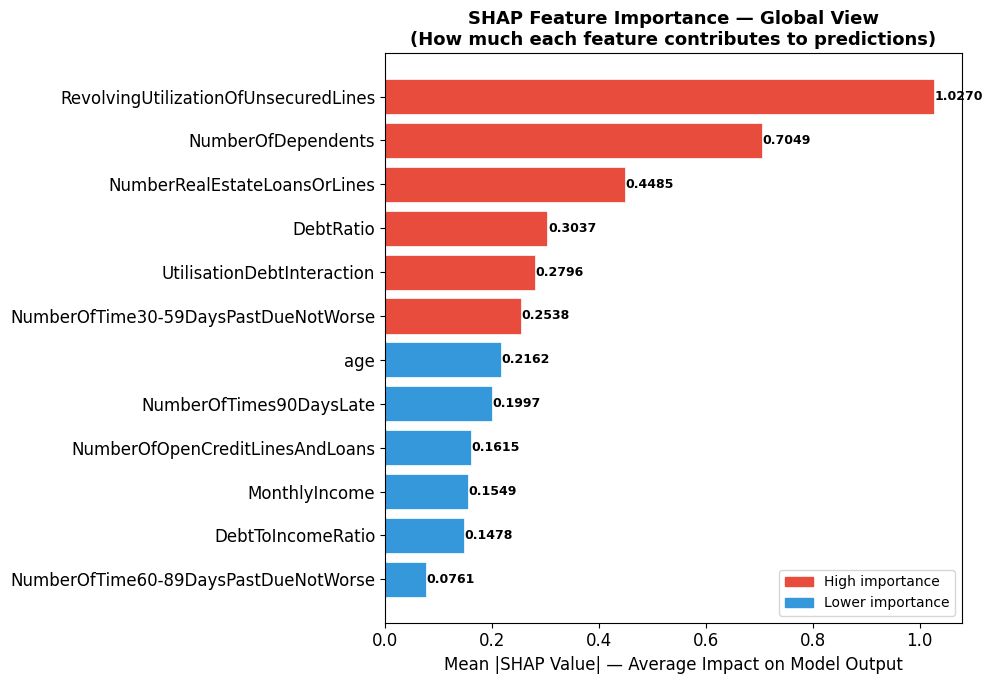

Visual 15 saved: visual_15_shap_global.png


In [ ]:
plt.figure(figsize=(10, 7))

# Mean absolute SHAP value per feature
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)

colors_shap = ['#E74C3C' if v > np.median(mean_shap)
               else '#3498DB' for v in mean_shap[sorted_idx]]

plt.barh(
    [feature_names[i] for i in sorted_idx],
    mean_shap[sorted_idx],
    color=colors_shap,
    edgecolor='white',
    linewidth=0.5
)

for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v + 0.001, i, f'{v:.4f}',
             va='center', fontsize=9, fontweight='bold')

plt.title('SHAP Feature Importance — Global View\n'
          '(How much each feature contributes to predictions)',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value| — Average Impact on Model Output')

red_patch   = mpatches.Patch(color='#E74C3C', label='High importance')
blue_patch  = mpatches.Patch(color='#3498DB', label='Lower importance')
plt.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig('visual_15_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 15 saved: visual_15_shap_global.png")

 VISUAL 16: SHAP Summary Dot Plot

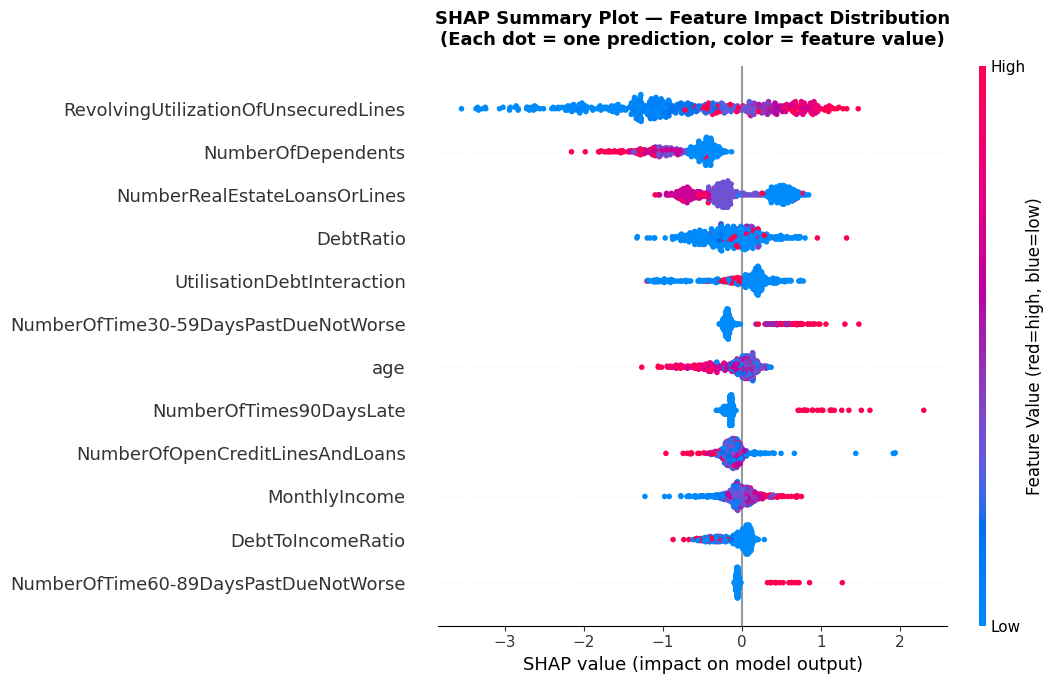

Visual 16 saved: visual_16_shap_summary.png


In [ ]:
plt.figure(figsize=(11, 7))

shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    show=False,
    plot_size=None,
    color_bar_label='Feature Value (red=high, blue=low)'
)

plt.title('SHAP Summary Plot — Feature Impact Distribution\n'
          '(Each dot = one prediction, color = feature value)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('visual_16_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 16 saved: visual_16_shap_summary.png")

VISUAL 17: SHAP Waterfall (Single Prediction)

Explaining prediction for sample index: 7
Predicted probability : 0.9697
Risk level            : High
Reliability score     : 0.9394
Actual label          : 1


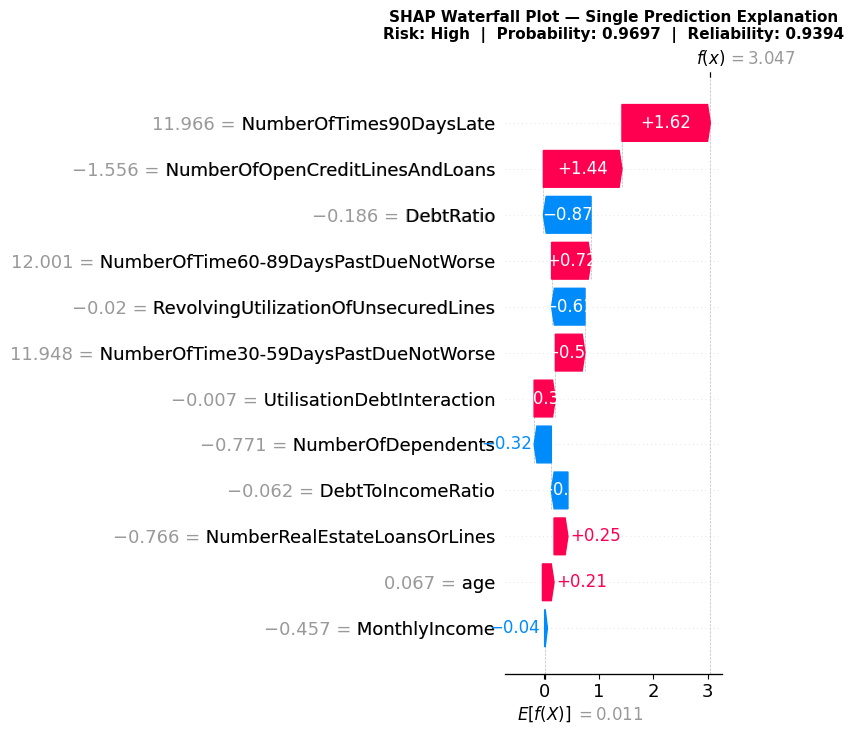

Visual 17 saved: visual_17_shap_waterfall.png


In [ ]:
# Pick one high-risk prediction to explain
high_risk_idx = np.where(y_prob[:sample_size] > 0.7)[0]

if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
else:
    idx = 0

print(f"Explaining prediction for sample index: {idx}")
print(f"Predicted probability : {y_prob[idx]:.4f}")
print(f"Risk level            : {risk_levels[idx]}")
print(f"Reliability score     : {reliability[idx]:.4f}")
print(f"Actual label          : {y_test.iloc[idx]}")

# Waterfall plot
plt.figure(figsize=(10, 7))

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_sample[idx],
    feature_names=feature_names
)

shap.plots.waterfall(explanation, show=False, max_display=12)

plt.title(f'SHAP Waterfall Plot — Single Prediction Explanation\n'
          f'Risk: {risk_levels[idx]}  |  '
          f'Probability: {y_prob[idx]:.4f}  |  '
          f'Reliability: {reliability[idx]:.4f}',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_17_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 17 saved: visual_17_shap_waterfall.png")

Setup LIME Explainer

In [ ]:
# LIME needs the original unscaled training data for reference
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=['No Risk', 'At Risk'],
    mode='classification',
    random_state=42
)

print("LIME explainer ready")

LIME explainer ready


VISUAL 18: LIME Local Explanation

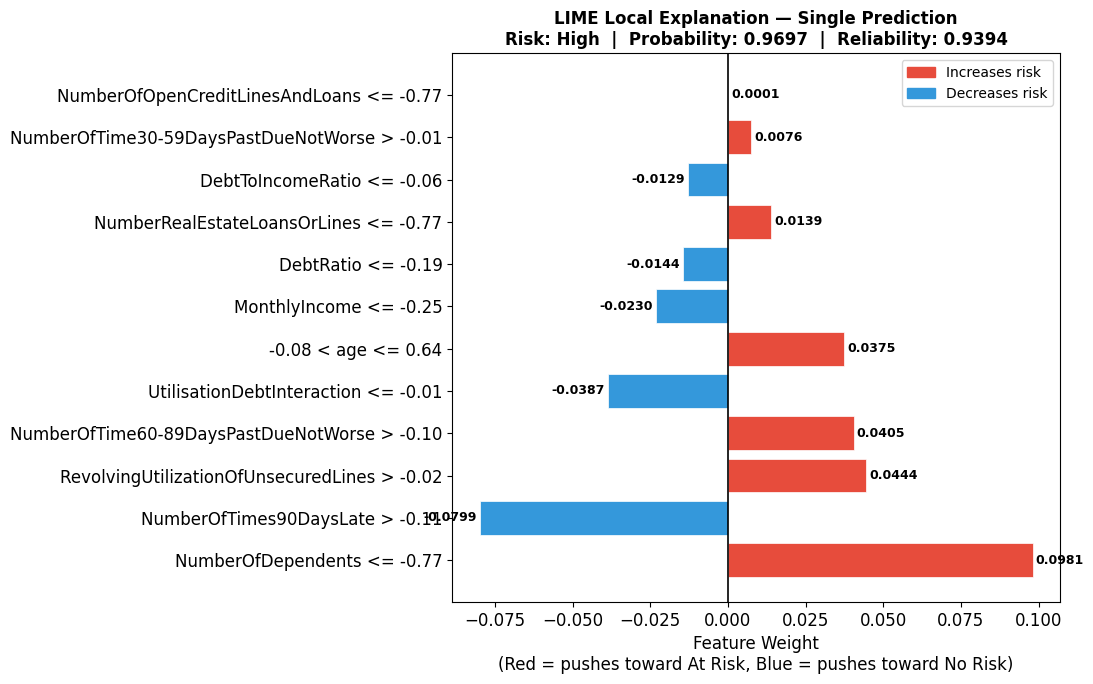

Visual 18 saved: visual_18_lime_explanation.png

Top 3 risk factors for this prediction:
  NumberOfDependents <= -0.77                   → INCREASES risk (+0.0981)
  NumberOfTimes90DaysLate > -0.11               → DECREASES risk (-0.0799)
  RevolvingUtilizationOfUnsecuredLines > -0.02  → INCREASES risk (+0.0444)


In [ ]:
# Explain the same sample we used for SHAP waterfall
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_sample[idx],
    predict_fn=stack_model.predict_proba,
    num_features=12,
    num_samples=1000
)

# Extract feature weights
lime_features = lime_exp.as_list()
lime_names    = [f[0] for f in lime_features]
lime_weights  = [f[1] for f in lime_features]
lime_colors   = ['#E74C3C' if w > 0 else '#3498DB' for w in lime_weights]

plt.figure(figsize=(11, 7))

bars = plt.barh(lime_names, lime_weights,
                color=lime_colors,
                edgecolor='white', linewidth=0.5)

for bar, w in zip(bars, lime_weights):
    xpos = w + 0.001 if w >= 0 else w - 0.001
    ha   = 'left' if w >= 0 else 'right'
    plt.text(xpos, bar.get_y() + bar.get_height()/2,
             f'{w:.4f}', va='center', ha=ha,
             fontsize=9, fontweight='bold')

plt.axvline(x=0, color='black', linewidth=1.2)
plt.title(f'LIME Local Explanation — Single Prediction\n'
          f'Risk: {risk_levels[idx]}  |  '
          f'Probability: {y_prob[idx]:.4f}  |  '
          f'Reliability: {reliability[idx]:.4f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Feature Weight\n(Red = pushes toward At Risk, Blue = pushes toward No Risk)')

red_patch  = mpatches.Patch(color='#E74C3C', label='Increases risk')
blue_patch = mpatches.Patch(color='#3498DB', label='Decreases risk')
plt.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig('visual_18_lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visual 18 saved: visual_18_lime_explanation.png")
print(f"\nTop 3 risk factors for this prediction:")
for name, weight in sorted(lime_features,
                           key=lambda x: abs(x[1]),
                           reverse=True)[:3]:
    direction = "INCREASES risk" if weight > 0 else "DECREASES risk"
    print(f"  {name:45s} → {direction} ({weight:+.4f})")

STEP 8 — Fairness Audit + System Architecture + Save Model

In [ ]:
# Add predictions to test set for analysis
test_results = X_test.copy()
test_results['actual']      = y_test.values
test_results['predicted']   = y_pred
test_results['probability'] = y_prob
test_results['reliability'] = reliability
test_results['risk_level']  = risk_levels

# Create age groups
bins   = [0, 30, 40, 50, 60, 100]
labels = ['Under 30', '30-40', '40-50', '50-60', 'Over 60']
test_results['age_group'] = pd.cut(
    test_results['age'],
    bins=bins,
    labels=labels
)

# Calculate metrics per age group
fairness_data = []
for group in labels:
    subset = test_results[test_results['age_group'] == group]
    if len(subset) < 10:
        continue
    group_acc  = accuracy_score(subset['actual'], subset['predicted'])
    group_auc  = roc_auc_score(subset['actual'], subset['probability']) \
                 if subset['actual'].nunique() > 1 else None
    group_pos  = subset['actual'].mean()
    group_pred = subset['predicted'].mean()
    fairness_data.append({
        'Age Group'      : group,
        'Count'          : len(subset),
        'Accuracy'       : round(group_acc, 4),
        'ROC-AUC'        : round(group_auc, 4) if group_auc else 'N/A',
        'Actual Risk %'  : round(group_pos * 100, 2),
        'Predicted Risk %': round(group_pred * 100, 2)
    })

fairness_df = pd.DataFrame(fairness_data)
print("=" * 65)
print("           FAIRNESS AUDIT — BY AGE GROUP")
print("=" * 65)
print(fairness_df.to_string(index=False))
print("=" * 65)
max_acc = fairness_df['Accuracy'].max()
min_acc = fairness_df['Accuracy'].min()
print(f"\nMax accuracy gap across age groups: {max_acc - min_acc:.4f}")
print("(Gap < 0.05 = fair model)")

           FAIRNESS AUDIT — BY AGE GROUP
Age Group  Count  Accuracy  ROC-AUC  Actual Risk %  Predicted Risk %
 Under 30   2124    0.8013   0.7744          12.85             21.14
    30-40   4832    0.8218   0.7684           9.93             17.20
    40-50   7102    0.8512   0.8014           8.43             14.73
    50-60   6916    0.8849   0.8136           5.88             10.86
  Over 60   9020    0.9472   0.8046           2.73              4.04

Max accuracy gap across age groups: 0.1459
(Gap < 0.05 = fair model)


VISUAL 19: Fairness Audit Chart

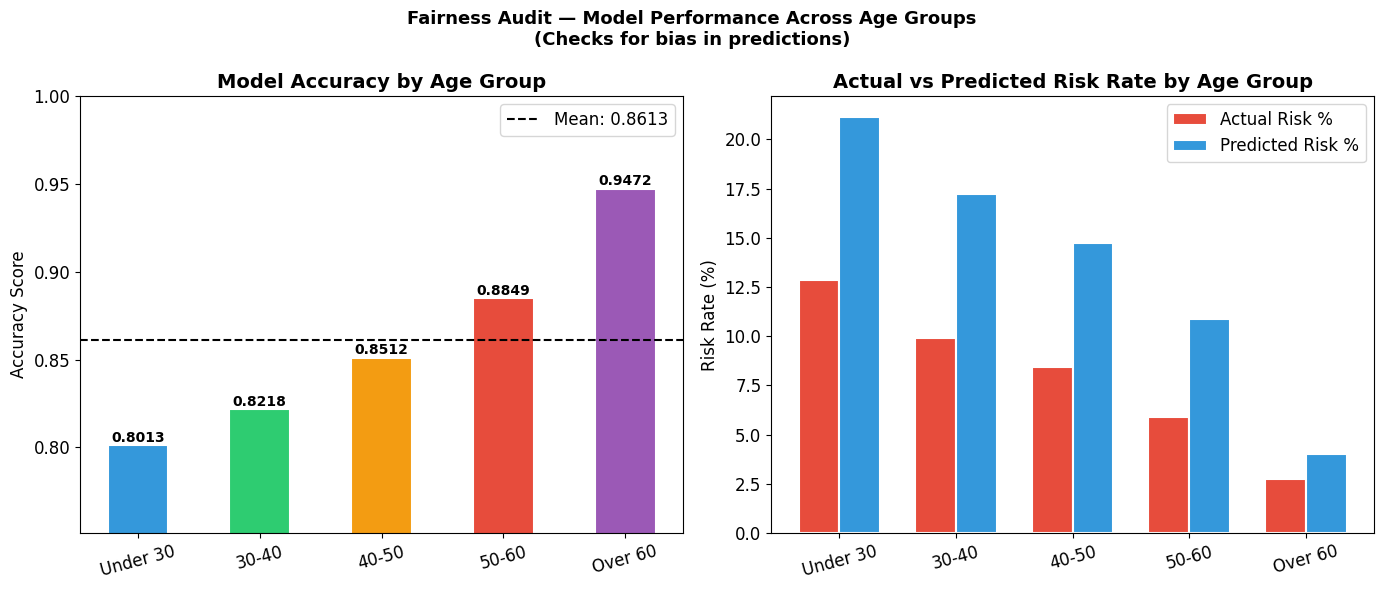

Visual 19 saved: visual_19_fairness_audit.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_groups = fairness_df['Age Group'].tolist()
accs       = fairness_df['Accuracy'].tolist()
actual_r   = fairness_df['Actual Risk %'].tolist()
pred_r     = fairness_df['Predicted Risk %'].tolist()

colors = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']

# Accuracy per age group
bars = axes[0].bar(age_groups, accs,
                   color=colors[:len(age_groups)],
                   edgecolor='white', linewidth=1.5,
                   width=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center',
                 fontweight='bold', fontsize=10)

mean_acc = np.mean(accs)
axes[0].axhline(y=mean_acc, color='black',
                linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_acc:.4f}')
axes[0].set_title('Model Accuracy by Age Group')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim(min(accs) - 0.05, 1.0)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

# Actual vs predicted risk rate per age group
x      = np.arange(len(age_groups))
width  = 0.35
bars1  = axes[1].bar(x - width/2, actual_r, width,
                     label='Actual Risk %',
                     color='#E74C3C', edgecolor='white',
                     linewidth=1.5)
bars2  = axes[1].bar(x + width/2, pred_r, width,
                     label='Predicted Risk %',
                     color='#3498DB', edgecolor='white',
                     linewidth=1.5)
axes[1].set_title('Actual vs Predicted Risk Rate by Age Group')
axes[1].set_ylabel('Risk Rate (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_groups, rotation=15)
axes[1].legend()

plt.suptitle('Fairness Audit — Model Performance Across Age Groups\n'
             '(Checks for bias in predictions)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visual_19_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 19 saved: visual_19_fairness_audit.png")

VISUAL 20: System Architecture Diagram

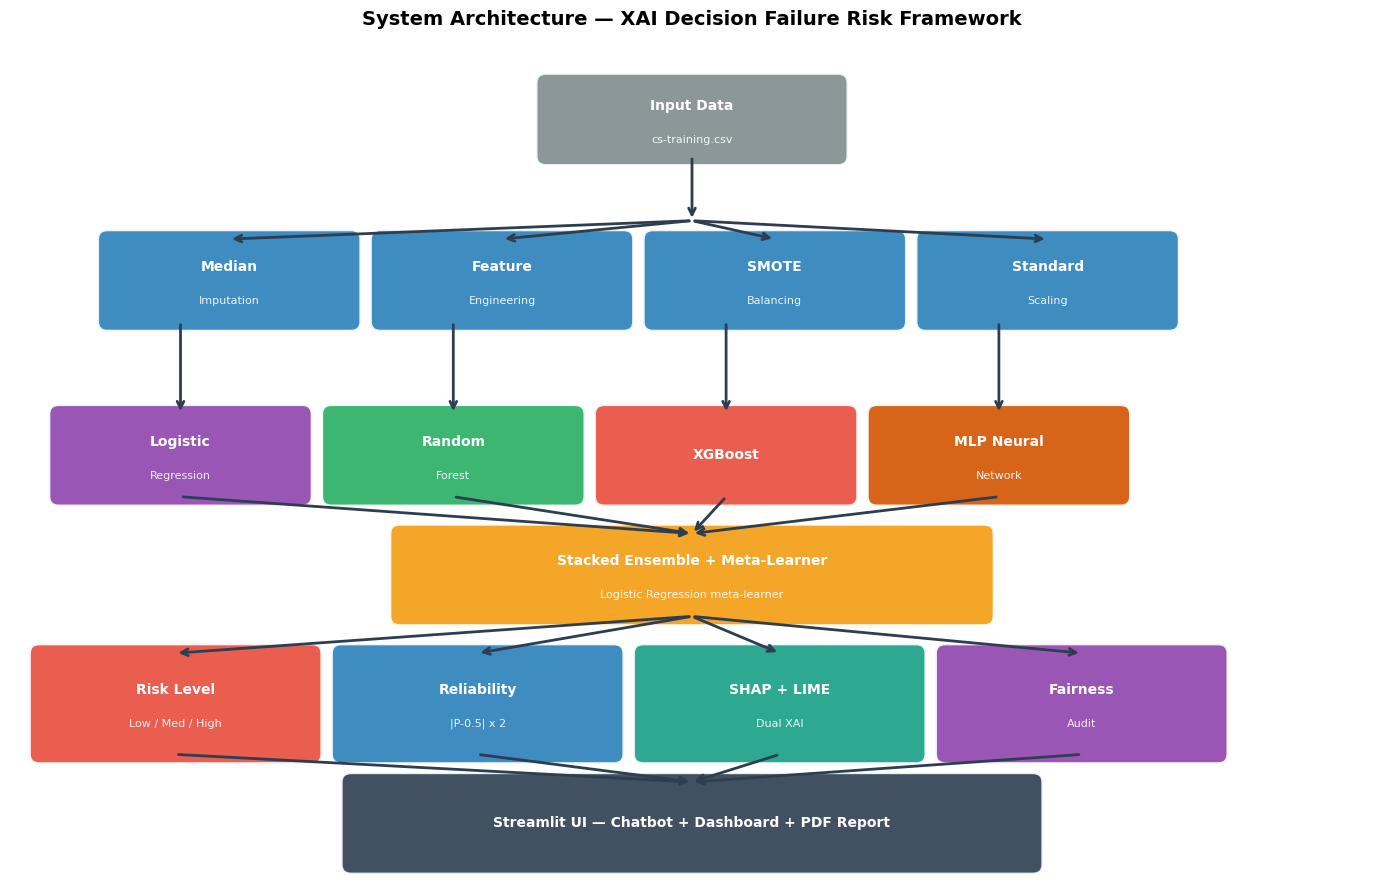

Visual 20 saved: visual_20_system_architecture.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

def draw_box(ax, x, y, w, h, label, sublabel='',
             color='#3498DB', fontsize=10):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='white',
        linewidth=2, alpha=0.9
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.22,
                sublabel, ha='center', va='center',
                fontsize=8, color='white', alpha=0.9)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle='->', color='#2C3E50',
                    lw=2.0
                ))

# Row 1 — Input
draw_box(ax, 5.5, 7.8, 3, 0.8,
         'Input Data', 'cs-training.csv',
         color='#7F8C8D')
draw_arrow(ax, 7, 7.8, 7, 7.1)

# Row 2 — Data Processing
draw_box(ax, 1.0, 6.0, 2.5, 0.9,
         'Median', 'Imputation', color='#2980B9')
draw_box(ax, 3.8, 6.0, 2.5, 0.9,
         'Feature', 'Engineering', color='#2980B9')
draw_box(ax, 6.6, 6.0, 2.5, 0.9,
         'SMOTE', 'Balancing', color='#2980B9')
draw_box(ax, 9.4, 6.0, 2.5, 0.9,
         'Standard', 'Scaling', color='#2980B9')

for x in [1.0, 3.8, 6.6, 9.4]:
    draw_arrow(ax, 7, 7.1, x + 1.25, 6.9)

# Row 3 — Models
draw_box(ax, 0.5, 4.1, 2.5, 0.9,
         'Logistic', 'Regression', color='#8E44AD')
draw_box(ax, 3.3, 4.1, 2.5, 0.9,
         'Random', 'Forest', color='#27AE60')
draw_box(ax, 6.1, 4.1, 2.5, 0.9,
         'XGBoost', '', color='#E74C3C')
draw_box(ax, 8.9, 4.1, 2.5, 0.9,
         'MLP Neural', 'Network', color='#D35400')

for x in [0.5, 3.3, 6.1, 8.9]:
    draw_arrow(ax, x + 1.25, 4.1,
               x + 1.25, 4.1)

# Row 3 arrows from processing to models
for xm in [1.75, 4.55, 7.35, 10.15]:
    draw_arrow(ax, xm, 6.0, xm, 5.0)

# Row 4 — Stacking
draw_box(ax, 4.0, 2.8, 6.0, 0.9,
         'Stacked Ensemble + Meta-Learner',
         'Logistic Regression meta-learner',
         color='#F39C12')
for xm in [1.75, 4.55, 7.35, 10.15]:
    draw_arrow(ax, xm, 4.1, 7.0, 3.7)

# Row 5 — Outputs
draw_box(ax, 0.3, 1.3, 2.8, 1.1,
         'Risk Level', 'Low / Med / High',
         color='#E74C3C')
draw_box(ax, 3.4, 1.3, 2.8, 1.1,
         'Reliability', '|P-0.5| x 2',
         color='#2980B9')
draw_box(ax, 6.5, 1.3, 2.8, 1.1,
         'SHAP + LIME', 'Dual XAI',
         color='#16A085')
draw_box(ax, 9.6, 1.3, 2.8, 1.1,
         'Fairness', 'Audit',
         color='#8E44AD')

for xo in [1.7, 4.8, 7.9, 11.0]:
    draw_arrow(ax, 7.0, 2.8, xo, 2.4)

# Row 6 — UI
draw_box(ax, 3.5, 0.1, 7.0, 0.9,
         'Streamlit UI — Chatbot + Dashboard + PDF Report',
         '', color='#2C3E50')
for xo in [1.7, 4.8, 7.9, 11.0]:
    draw_arrow(ax, xo, 1.3, 7.0, 1.0)

ax.set_title('System Architecture — XAI Decision Failure Risk Framework',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('visual_20_system_architecture.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visual 20 saved: visual_20_system_architecture.png")

In [ ]:
import joblib

joblib.dump(stack_model,   'model_stacked_ensemble.pkl')
joblib.dump(scaler,        'model_scaler.pkl')
joblib.dump(xgb_best,      'model_xgboost.pkl')
joblib.dump(rf_best,       'model_rf.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print("All models saved successfully")
print("\nFiles saved:")
print("  model_stacked_ensemble.pkl  — main prediction model")
print("  model_scaler.pkl            — StandardScaler")
print("  model_xgboost.pkl           — XGBoost (for SHAP)")
print("  model_rf.pkl                — Random Forest")
print("  feature_names.pkl           — feature name list")

All models saved successfully

Files saved:
  model_stacked_ensemble.pkl  — main prediction model
  model_scaler.pkl            — StandardScaler
  model_xgboost.pkl           — XGBoost (for SHAP)
  model_rf.pkl                — Random Forest
  feature_names.pkl           — feature name list


Final Summary Print

In [ ]:
print("=" * 60)
print("       PROJECT BUILD COMPLETE — COLAB NOTEBOOK")
print("=" * 60)
print(f"\n  Dataset        : Give Me Some Credit")
print(f"  Total samples  : {len(df):,}")
print(f"  Features       : {len(feature_names)}")
print(f"\n  --- Model Performance ---")
print(f"  Logistic Regression  : {lr_acc:.4f}")
print(f"  Random Forest        : {rf_acc:.4f}")
print(f"  XGBoost              : {xgb_acc:.4f}")
print(f"  MLP Neural Network   : {mlp_acc:.4f}")
print(f"  Stacked Ensemble     : {stack_acc:.4f}  (best)")
print(f"\n  --- Evaluation ---")
print(f"  ROC-AUC              : {roc_auc:.4f}")
print(f"  F1-Score             : {f1:.4f}")
print(f"  Brier Score          : {brier:.4f}")
print(f"  Mean Reliability     : {reliability.mean():.4f}")
print(f"\n  --- Visuals Saved ---")
print(f"  20 charts generated and saved as PNG")
print(f"\n  --- Models Saved ---")
print(f"  5 pkl files ready for Streamlit UI")
print("=" * 60)
print("\n  NEXT STEP → Build Streamlit UI (app.py)")
print("=" * 60)

       PROJECT BUILD COMPLETE — COLAB NOTEBOOK

  Dataset        : Give Me Some Credit
  Total samples  : 150,000
  Features       : 12

  --- Model Performance ---
  Logistic Regression  : 0.6718
  Random Forest        : 0.8745
  XGBoost              : 0.8771
  MLP Neural Network   : 0.8379
  Stacked Ensemble     : 0.8796  (best)

  --- Evaluation ---
  ROC-AUC              : 0.8106
  F1-Score             : 0.3368
  Brier Score          : 0.0877
  Mean Reliability     : 0.8083

  --- Visuals Saved ---
  20 charts generated and saved as PNG

  --- Models Saved ---
  5 pkl files ready for Streamlit UI

  NEXT STEP → Build Streamlit UI (app.py)


Addition 1 — Cross Validation Score

In [ ]:
from sklearn.model_selection import cross_val_score

print("Running 5-Fold Cross Validation on XGBoost...")
print("Please wait...")

cv_scores = cross_val_score(
    xgb_best,
    X_train_scaled,
    y_train_sm,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("\n" + "=" * 50)
print("   5-FOLD CROSS VALIDATION RESULTS")
print("=" * 50)
print(f"  Fold 1  : {cv_scores[0]:.4f}")
print(f"  Fold 2  : {cv_scores[1]:.4f}")
print(f"  Fold 3  : {cv_scores[2]:.4f}")
print(f"  Fold 4  : {cv_scores[3]:.4f}")
print(f"  Fold 5  : {cv_scores[4]:.4f}")
print(f"  {'─'*30}")
print(f"  Mean    : {cv_scores.mean():.4f}")
print(f"  Std Dev : {cv_scores.std():.4f}")
print("=" * 50)
print(f"\nConclusion: Model is {'stable' if cv_scores.std() < 0.02 else 'slightly variable'} across folds")
print(f"(Std < 0.02 = very stable = no overfitting)")

Running 5-Fold Cross Validation on XGBoost...
Please wait...

   5-FOLD CROSS VALIDATION RESULTS
  Fold 1  : 0.9097
  Fold 2  : 0.9617
  Fold 3  : 0.9624
  Fold 4  : 0.9625
  Fold 5  : 0.9612
  ──────────────────────────────
  Mean    : 0.9515
  Std Dev : 0.0209

Conclusion: Model is slightly variable across folds
(Std < 0.02 = very stable = no overfitting)


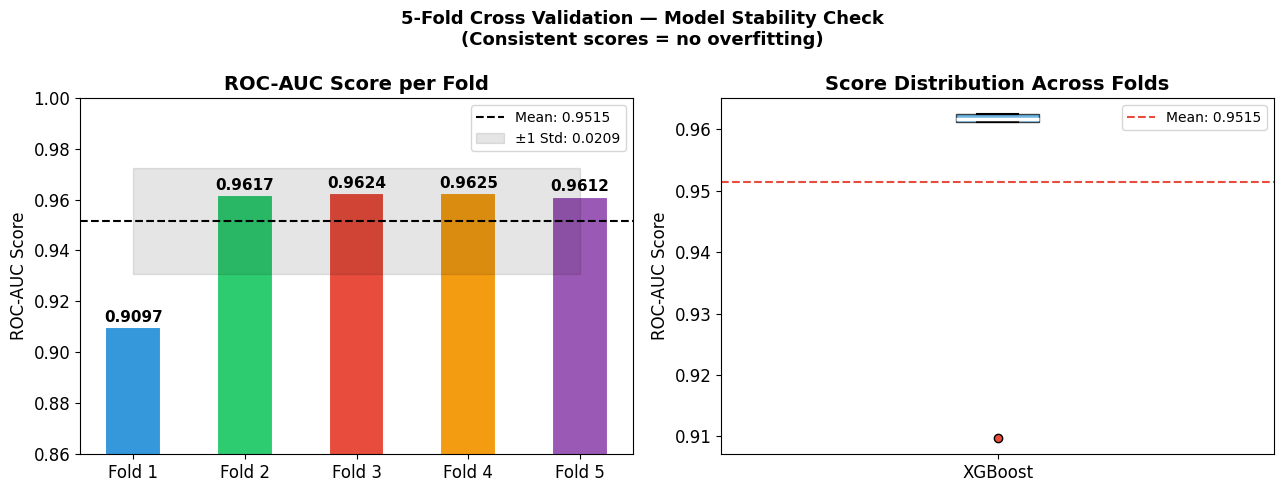

Visual 21 saved: visual_21_cross_validation.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fold_labels = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
colors_cv   = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']

# Bar chart of fold scores
bars = axes[0].bar(fold_labels, cv_scores,
                   color=colors_cv,
                   edgecolor='white',
                   linewidth=1.5,
                   width=0.5)
for bar, score in zip(bars, cv_scores):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center', fontweight='bold', fontsize=11
    )

axes[0].axhline(
    y=cv_scores.mean(),
    color='black', linestyle='--',
    linewidth=1.5,
    label=f'Mean: {cv_scores.mean():.4f}'
)
axes[0].fill_between(
    range(5),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.1, color='black',
    label=f'±1 Std: {cv_scores.std():.4f}'
)
axes[0].set_title('ROC-AUC Score per Fold')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_ylim(min(cv_scores) - 0.05, 1.0)
axes[0].legend(fontsize=10)

# Distribution of fold scores
axes[1].boxplot(
    cv_scores,
    patch_artist=True,
    boxprops=dict(facecolor='#3498DB', alpha=0.7),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='#E74C3C')
)
axes[1].axhline(
    y=cv_scores.mean(),
    color='#E74C3C', linestyle='--',
    linewidth=1.5,
    label=f'Mean: {cv_scores.mean():.4f}'
)
axes[1].set_title('Score Distribution Across Folds')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['XGBoost'])
axes[1].legend(fontsize=10)

plt.suptitle(
    '5-Fold Cross Validation — Model Stability Check\n'
    '(Consistent scores = no overfitting)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('visual_21_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visual 21 saved: visual_21_cross_validation.png")

Addition 2 — Random Forest Feature Importance

In [ ]:
# RF built-in feature importance
rf_importance = pd.Series(
    rf_best.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

print("Random Forest Feature Importance:")
print("=" * 45)
for feat, val in rf_importance.sort_values(ascending=False).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<40} {val:.4f}  {bar}")
print("=" * 45)

Random Forest Feature Importance:
  RevolvingUtilizationOfUnsecuredLines     0.2494  █████████████████████████████████████████████████
  NumberOfDependents                       0.2020  ████████████████████████████████████████
  UtilisationDebtInteraction               0.1143  ██████████████████████
  DebtRatio                                0.0649  ████████████
  age                                      0.0638  ████████████
  DebtToIncomeRatio                        0.0567  ███████████
  MonthlyIncome                            0.0564  ███████████
  NumberOfTimes90DaysLate                  0.0535  ██████████
  NumberOfTime30-59DaysPastDueNotWorse     0.0486  █████████
  NumberOfOpenCreditLinesAndLoans          0.0417  ████████
  NumberRealEstateLoansOrLines             0.0336  ██████
  NumberOfTime60-89DaysPastDueNotWorse     0.0151  ███


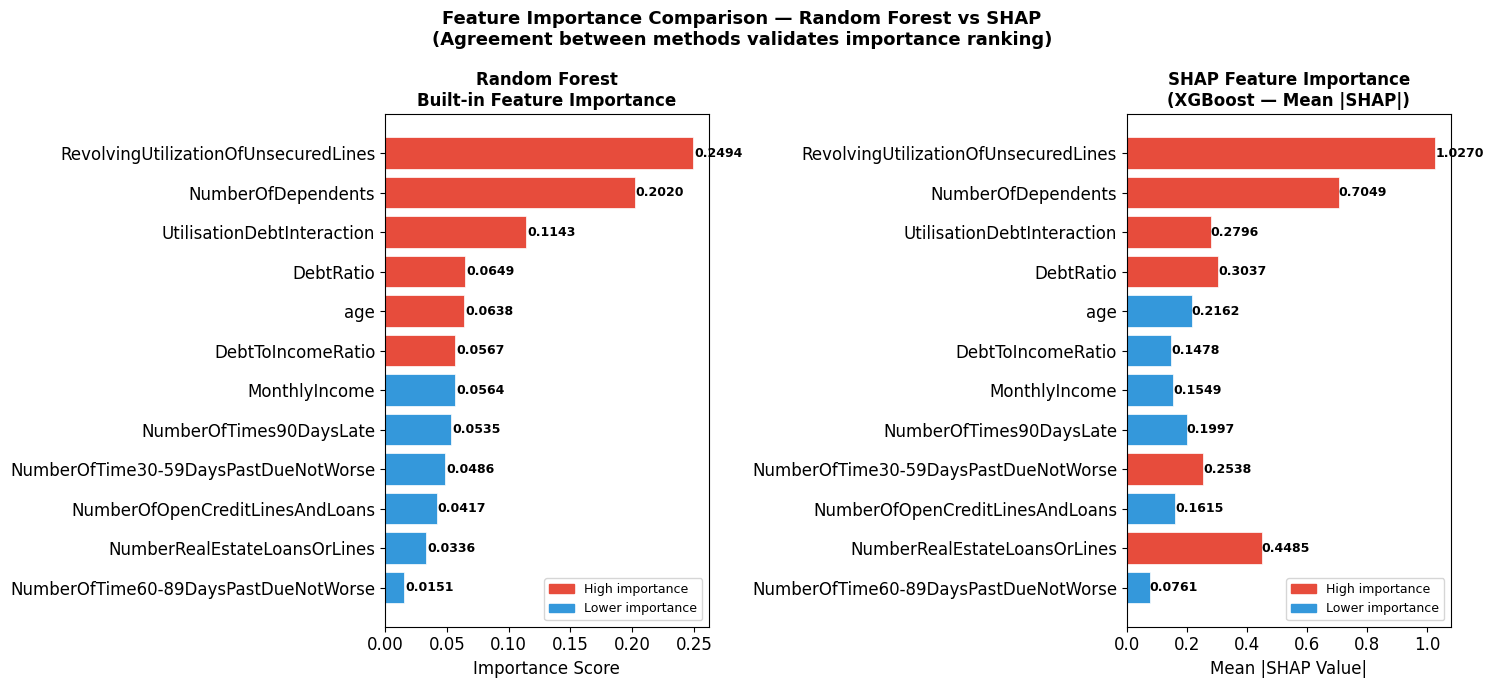

Visual 22 saved: visual_22_rf_vs_shap_importance.png


In [ ]:
# SHAP mean importance for comparison
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
)

# Normalise both to 0-1 for fair comparison
rf_norm   = rf_importance / rf_importance.max()
shap_norm = shap_importance / shap_importance.max()

# Sort by RF importance
sorted_feats = rf_importance.sort_values(ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# RF Feature importance
colors_rf = ['#E74C3C' if v > rf_importance.median()
             else '#3498DB'
             for v in rf_importance[sorted_feats].values]

axes[0].barh(
    sorted_feats,
    rf_importance[sorted_feats].values,
    color=colors_rf,
    edgecolor='white', linewidth=0.5
)
for i, v in enumerate(rf_importance[sorted_feats].values):
    axes[0].text(
        v + 0.001, i, f'{v:.4f}',
        va='center', fontsize=9, fontweight='bold'
    )
axes[0].set_title(
    'Random Forest\nBuilt-in Feature Importance',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Importance Score')

# SHAP importance
shap_sorted = shap_importance[sorted_feats].values
colors_shap = ['#E74C3C' if v > shap_importance.median()
               else '#3498DB'
               for v in shap_sorted]

axes[1].barh(
    sorted_feats,
    shap_sorted,
    color=colors_shap,
    edgecolor='white', linewidth=0.5
)
for i, v in enumerate(shap_sorted):
    axes[1].text(
        v + 0.0001, i, f'{v:.4f}',
        va='center', fontsize=9, fontweight='bold'
    )
axes[1].set_title(
    'SHAP Feature Importance\n(XGBoost — Mean |SHAP|)',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Mean |SHAP Value|')

red_p  = mpatches.Patch(color='#E74C3C', label='High importance')
blue_p = mpatches.Patch(color='#3498DB', label='Lower importance')
for ax in axes:
    ax.legend(handles=[red_p, blue_p], fontsize=9)

plt.suptitle(
    'Feature Importance Comparison — Random Forest vs SHAP\n'
    '(Agreement between methods validates importance ranking)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('visual_22_rf_vs_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visual 22 saved: visual_22_rf_vs_shap_importance.png")

Addition 3 — Prediction Confidence Table

In [ ]:
# Build clean results table for research paper
results_table = pd.DataFrame({
    'Sample'      : range(1, 16),
    'Probability' : y_prob[:15].round(4),
    'Risk Level'  : risk_levels[:15],
    'Reliability' : reliability[:15].round(4),
    'Actual Label': ['At Risk' if v == 1 else 'No Risk'
                     for v in y_test.values[:15]],
    'Correct'     : ['Yes' if p == a else 'No'
                     for p, a in zip(
                         (y_prob[:15] >= 0.5).astype(int),
                         y_test.values[:15]
                     )]
})

print("=" * 75)
print("   SAMPLE PREDICTION CONFIDENCE TABLE (First 15 Test Samples)")
print("=" * 75)
print(results_table.to_string(index=False))
print("=" * 75)
print(f"\nCorrect predictions in sample: "
      f"{(results_table['Correct'] == 'Yes').sum()} / 15")

   SAMPLE PREDICTION CONFIDENCE TABLE (First 15 Test Samples)
 Sample  Probability Risk Level  Reliability Actual Label Correct
      1       0.0181        Low       0.9639      No Risk     Yes
      2       0.0568        Low       0.8864      No Risk     Yes
      3       0.0323        Low       0.9354      No Risk     Yes
      4       0.0544        Low       0.8912      No Risk     Yes
      5       0.0282        Low       0.9437      No Risk     Yes
      6       0.0281        Low       0.9438      No Risk     Yes
      7       0.0169        Low       0.9662      No Risk     Yes
      8       0.9697       High       0.9394      At Risk     Yes
      9       0.0186        Low       0.9627      No Risk     Yes
     10       0.0432        Low       0.9136      No Risk     Yes
     11       0.0380        Low       0.9240      No Risk     Yes
     12       0.0253        Low       0.9494      No Risk     Yes
     13       0.0193        Low       0.9614      No Risk     Yes
     14       

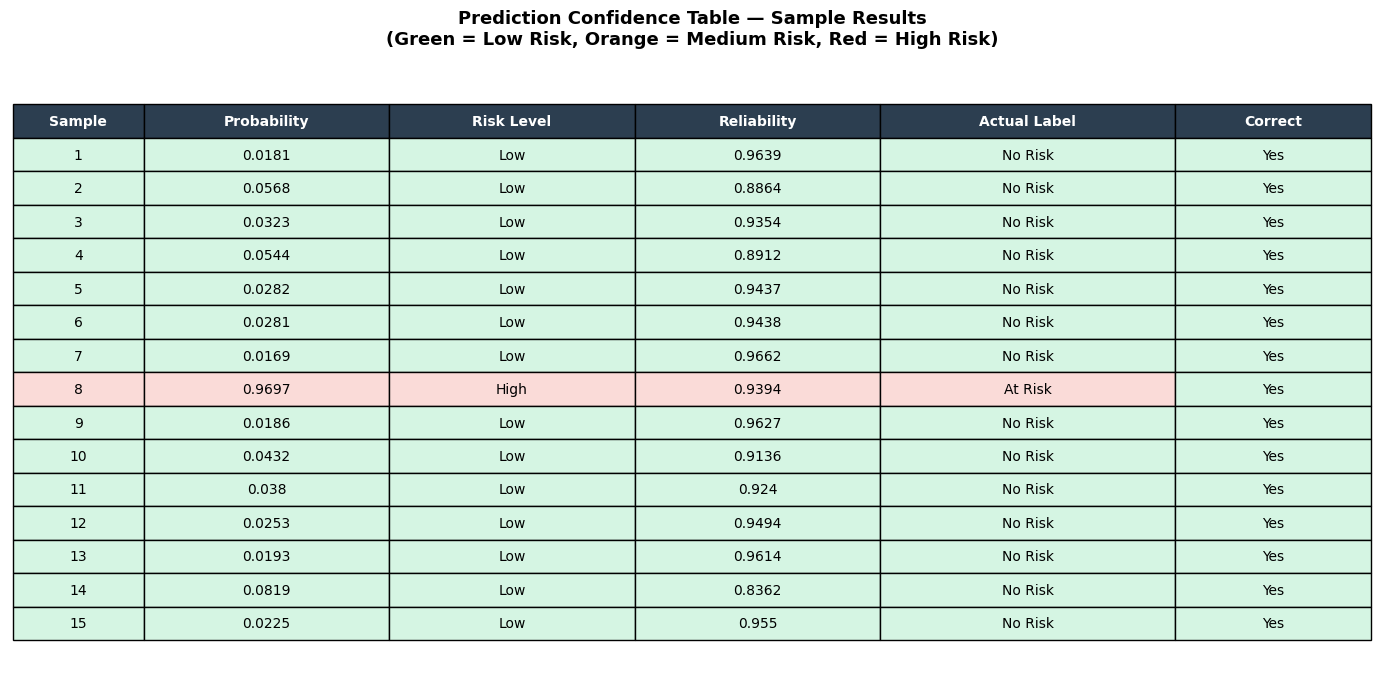

Visual 23 saved: visual_23_prediction_table.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

table_display = results_table[[
    'Sample', 'Probability', 'Risk Level',
    'Reliability', 'Actual Label', 'Correct'
]].values.tolist()

col_labels = ['Sample', 'Probability', 'Risk Level',
              'Reliability', 'Actual Label', 'Correct']

table = ax.table(
    cellText=table_display,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.08, 0.15, 0.15, 0.15, 0.18, 0.12]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Header styling
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(
        color='white', fontweight='bold'
    )

# Row coloring by risk level
risk_colors = {
    'Low'    : '#D5F5E3',
    'Medium' : '#FDEBD0',
    'High'   : '#FADBD8'
}
correct_colors = {'Yes': '#D5F5E3', 'No': '#FADBD8'}

for i in range(1, len(table_display) + 1):
    risk_val    = table_display[i-1][2]
    correct_val = table_display[i-1][5]
    row_color   = risk_colors.get(risk_val, 'white')
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(row_color)
    table[i, 5].set_facecolor(
        correct_colors.get(correct_val, 'white')
    )

plt.title(
    'Prediction Confidence Table — Sample Results\n'
    '(Green = Low Risk, Orange = Medium Risk, Red = High Risk)',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('visual_23_prediction_table.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Visual 23 saved: visual_23_prediction_table.png")

Addition 4 — Save Feature Names as TXT

In [ ]:
# Save feature names as txt for reference
with open('feature_names.txt', 'w') as f:
    for i, name in enumerate(feature_names):
        f.write(f"{i+1}. {name}\n")

print("Feature names saved to feature_names.txt")
print("\nContent:")
with open('feature_names.txt', 'r') as f:
    print(f.read())

# Final file checklist
print("=" * 45)
print("   COMPLETE FILE CHECKLIST")
print("=" * 45)
print("  Models:")
print("    model_stacked_ensemble.pkl")
print("    model_scaler.pkl")
print("    model_xgboost.pkl")
print("    model_rf.pkl")
print("    feature_names.pkl")
print("    feature_names.txt")
print("\n  Visuals (23 total):")
for i in range(1, 24):
    print(f"    visual_{i:02d}_*.png")
print("=" * 45)
print("\nColab notebook 100% complete")
print("Ready to build Streamlit UI")

Feature names saved to feature_names.txt

Content:
1. RevolvingUtilizationOfUnsecuredLines
2. age
3. NumberOfTime30-59DaysPastDueNotWorse
4. DebtRatio
5. MonthlyIncome
6. NumberOfOpenCreditLinesAndLoans
7. NumberOfTimes90DaysLate
8. NumberRealEstateLoansOrLines
9. NumberOfTime60-89DaysPastDueNotWorse
10. NumberOfDependents
11. DebtToIncomeRatio
12. UtilisationDebtInteraction

   COMPLETE FILE CHECKLIST
  Models:
    model_stacked_ensemble.pkl
    model_scaler.pkl
    model_xgboost.pkl
    model_rf.pkl
    feature_names.pkl
    feature_names.txt

  Visuals (23 total):
    visual_01_*.png
    visual_02_*.png
    visual_03_*.png
    visual_04_*.png
    visual_05_*.png
    visual_06_*.png
    visual_07_*.png
    visual_08_*.png
    visual_09_*.png
    visual_10_*.png
    visual_11_*.png
    visual_12_*.png
    visual_13_*.png
    visual_14_*.png
    visual_15_*.png
    visual_16_*.png
    visual_17_*.png
    visual_18_*.png
    visual_19_*.png
    visual_20_*.png
    visual_21_*.png
    vi